# Model Explainability with SHAP Values

**Author:** Phabel Antonio López Delgado, BSc.

This notebook provides a comprehensive introduction to model explainability using **SHAP (SHapley Additive exPlanations)**. It covers:

- **SHAP Overview** – understanding Shapley values and their application to machine learning models.
- **Global Interpretability** – feature importance and summary plots.
- **Local Interpretability** – individual prediction explanations (force plots, waterfall plots).
- **Case Study 1** – Breast Cancer dataset (Logistic Regression).
- **Case Study 2** – Loan Approval dataset (Logistic Regression and Decision Tree).

**Key Techniques & Libraries:**
- `shap` – SHAP value computation and visualisation
- `pandas`, `numpy` – data manipulation
- `sklearn.linear_model.LogisticRegression` – interpretable linear model
- `sklearn.tree.DecisionTreeClassifier` – tree‑based model
- `sklearn.model_selection.train_test_split` – data splitting
- `sklearn.metrics.classification_report` – model evaluation
- `matplotlib`, `seaborn` – static visualisation

**Data Sources:**
1. Breast Cancer Wisconsin Dataset – `sklearn.datasets.load_breast_cancer()`
2. Loan Approval Dataset – `https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv`

Both datasets are publicly available and widely used in machine learning benchmarks.

In [1]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All imports successful.")
print(f"SHAP version: {shap.__version__}")

All imports successful.
SHAP version: 0.49.1


## 1. Introduction to SHAP

SHAP (SHapley Additive exPlanations) is a game‑theoretic approach to explain the output of any machine learning model. It assigns each feature an importance value for a particular prediction, based on the concept of Shapley values from cooperative game theory.

**Key SHAP Visualisations:**
- **Summary Plot** – global feature importance (bar plot or dot plot).
- **Beeswarm Plot** – shows the distribution of SHAP values per feature.
- **Waterfall Plot** – explains a single prediction by showing how each feature contributes to the prediction.
- **Force Plot** – visualises the SHAP values as forces pushing the prediction from the base value.
- **Dependence Plot** – shows how a feature's SHAP value changes with its value.

In this notebook, we apply SHAP to two classification models: Logistic Regression (linear) and Decision Tree (non‑linear).

In [2]:
# %% Helper Functions
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Print classification report and return predictions."""
    y_pred = model.predict(X_test)
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred))
    # Confusion matrix (static)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['True 0', 'True 1'])
    plt.title(f'Confusion Matrix – {model_name}')
    plt.tight_layout()
    plt.savefig(f'plots/cm_{model_name.replace(" ", "_")}.png', dpi=300)
    plt.show()
    return y_pred

def shap_summary_plot(shap_values, X, feature_names, title='SHAP Summary Plot'):
    """Create a SHAP summary plot (beeswarm) with proper formatting."""
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'plots/{title.replace(" ", "_")}.png', dpi=300)
    plt.show()

# Part I: Breast Cancer Dataset – Logistic Regression

We train a logistic regression model on the Breast Cancer Wisconsin dataset and use SHAP to explain its predictions.

Model trained.

=== Logistic Regression (Breast Cancer) ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



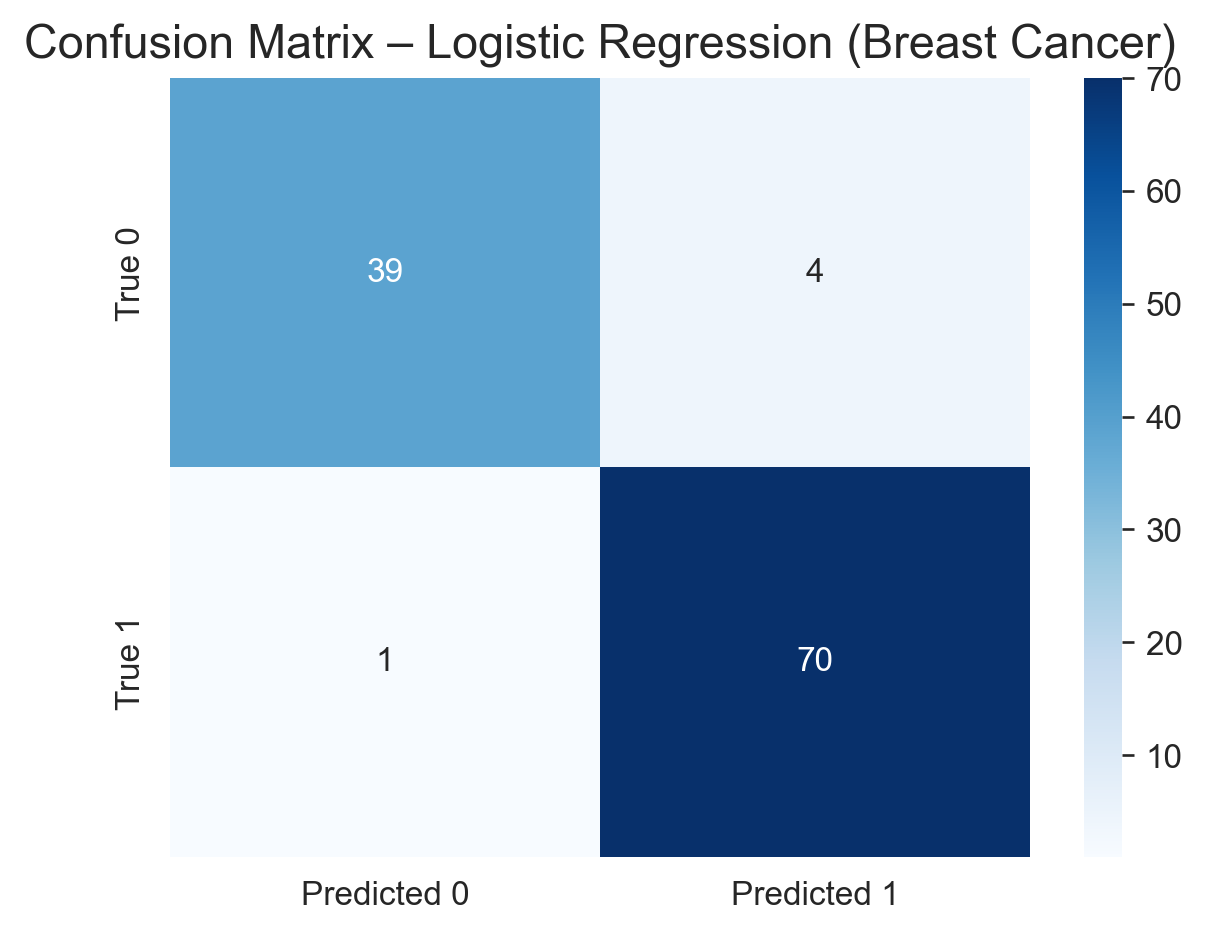

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [3]:
# %% Data Loading and Model Training
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_lr = LogisticRegression(max_iter=10000, random_state=42)
model_lr.fit(X_train, y_train)

print("Model trained.")
evaluate_model(model_lr, X_test, y_test, 'Logistic Regression (Breast Cancer)')

### 1.1 SHAP Analysis

We create a SHAP explainer for the logistic regression model and compute SHAP values for the test set.

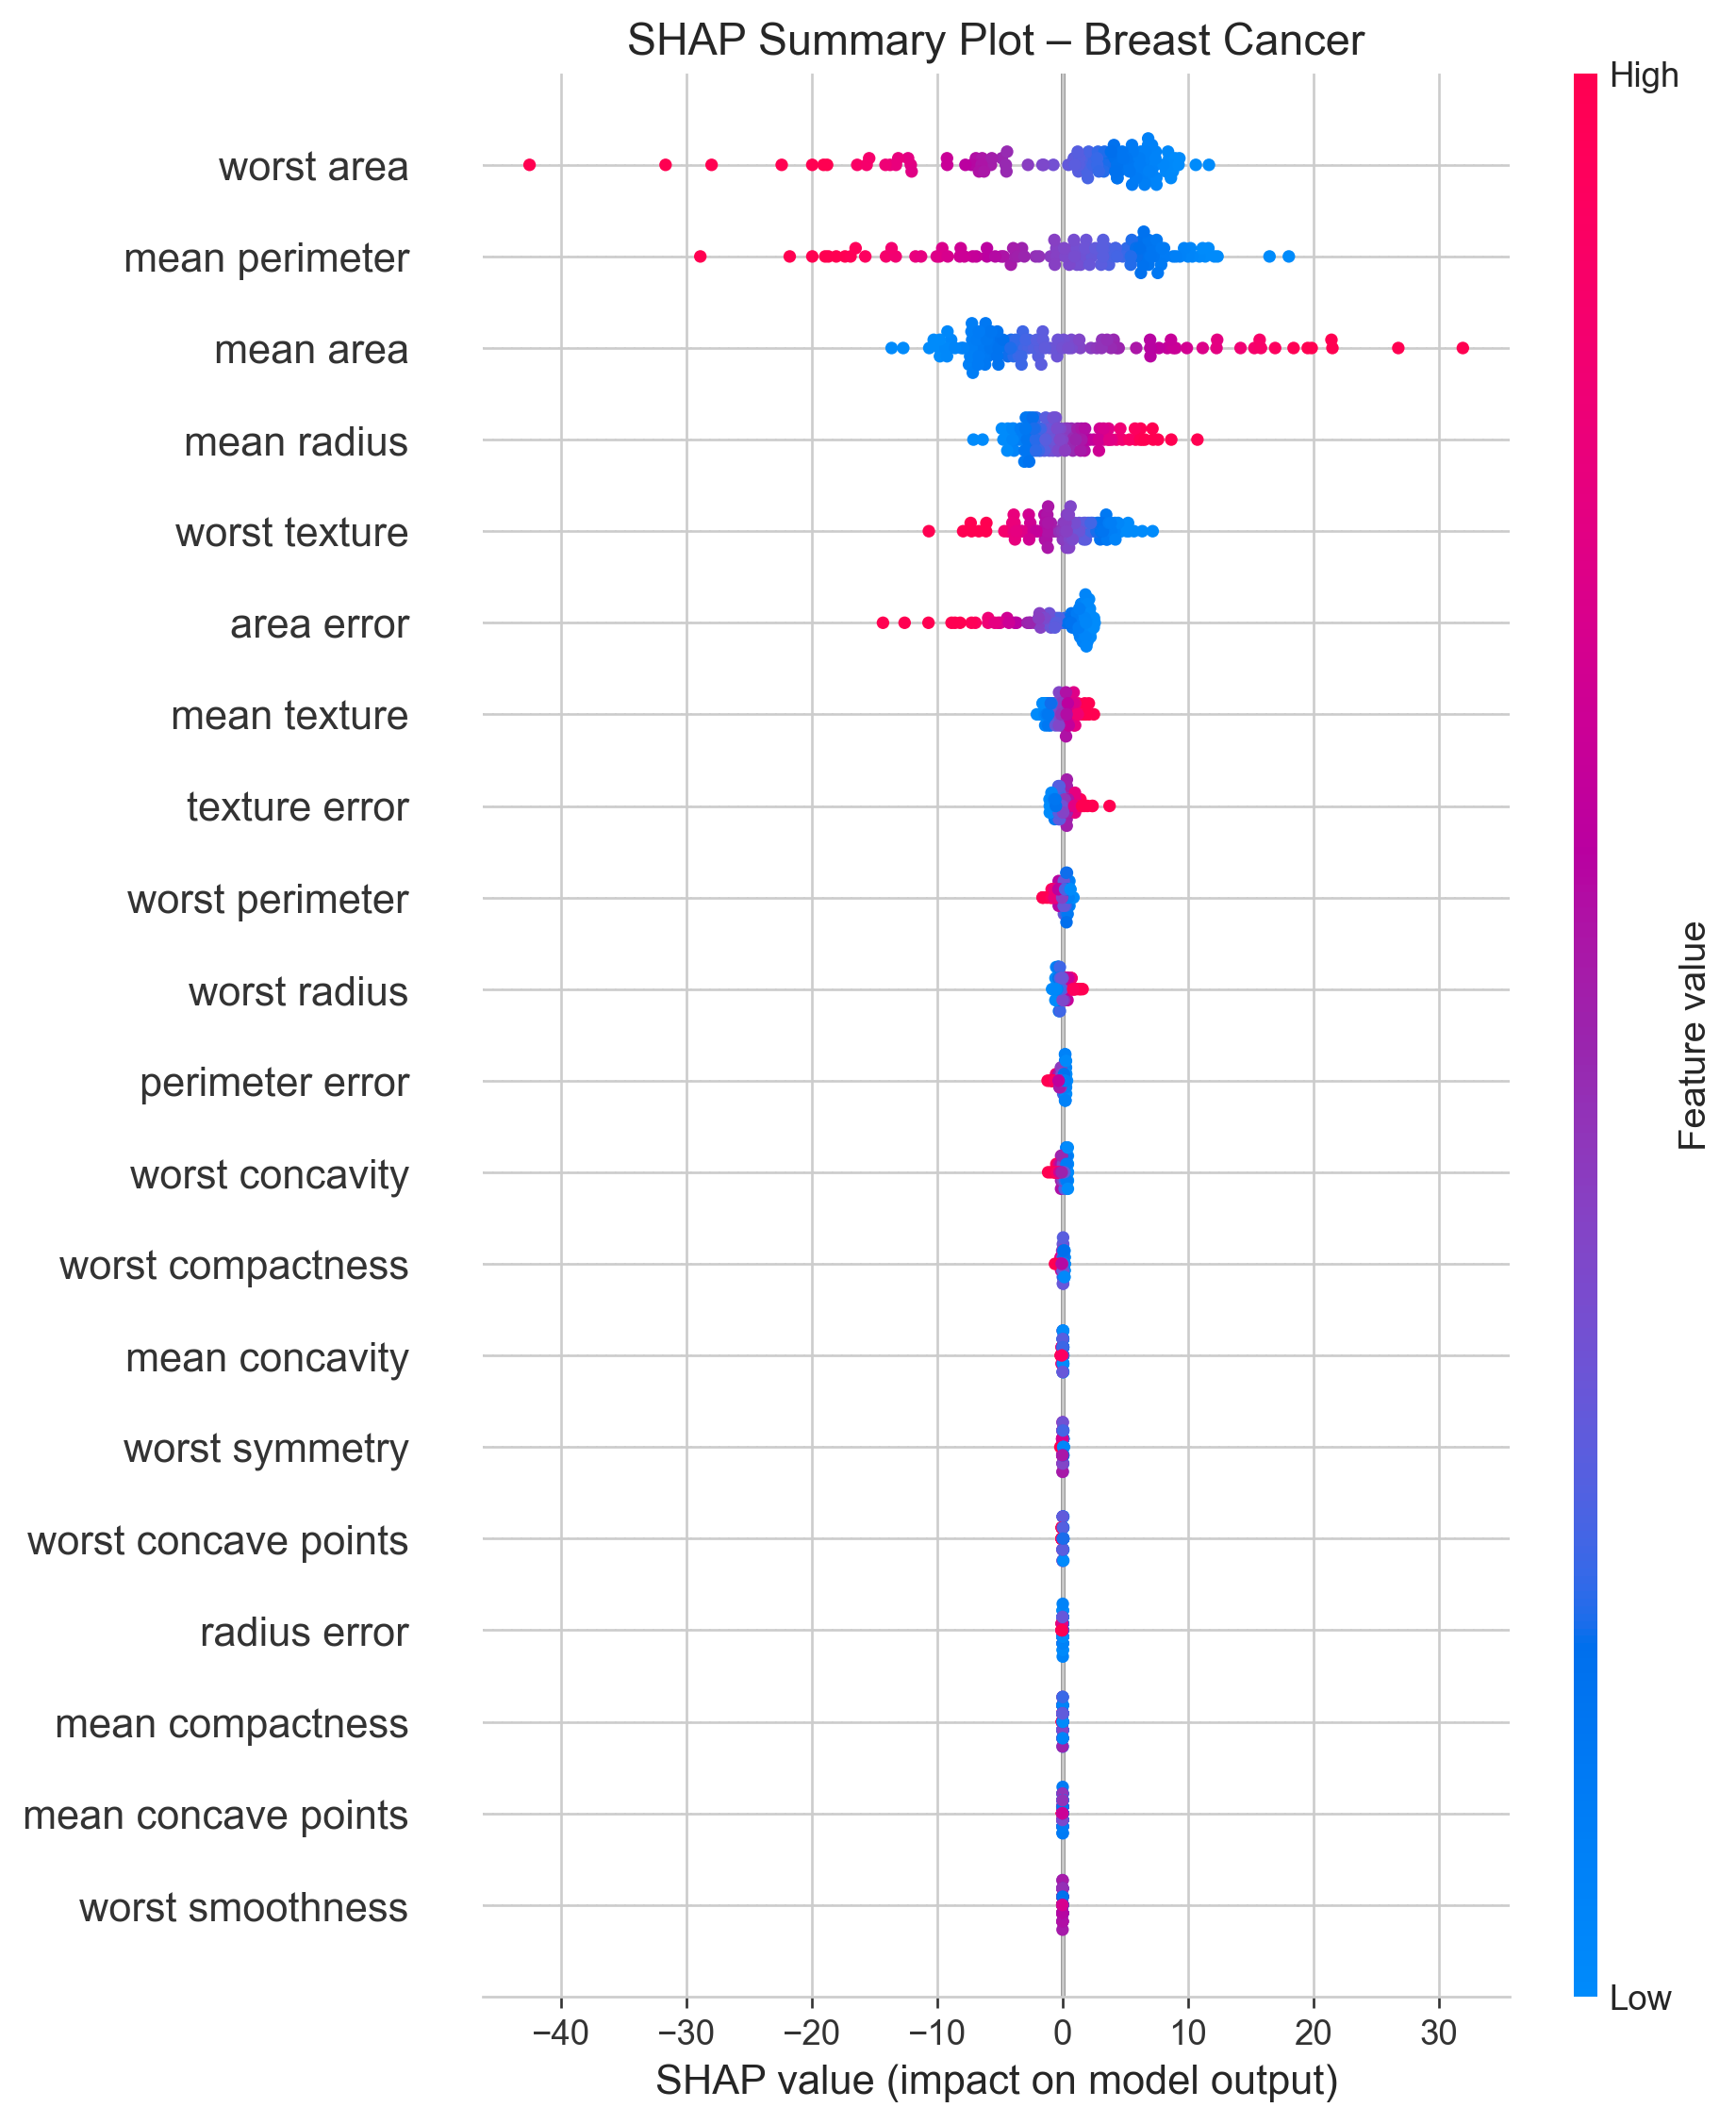

<Figure size 768x576 with 0 Axes>

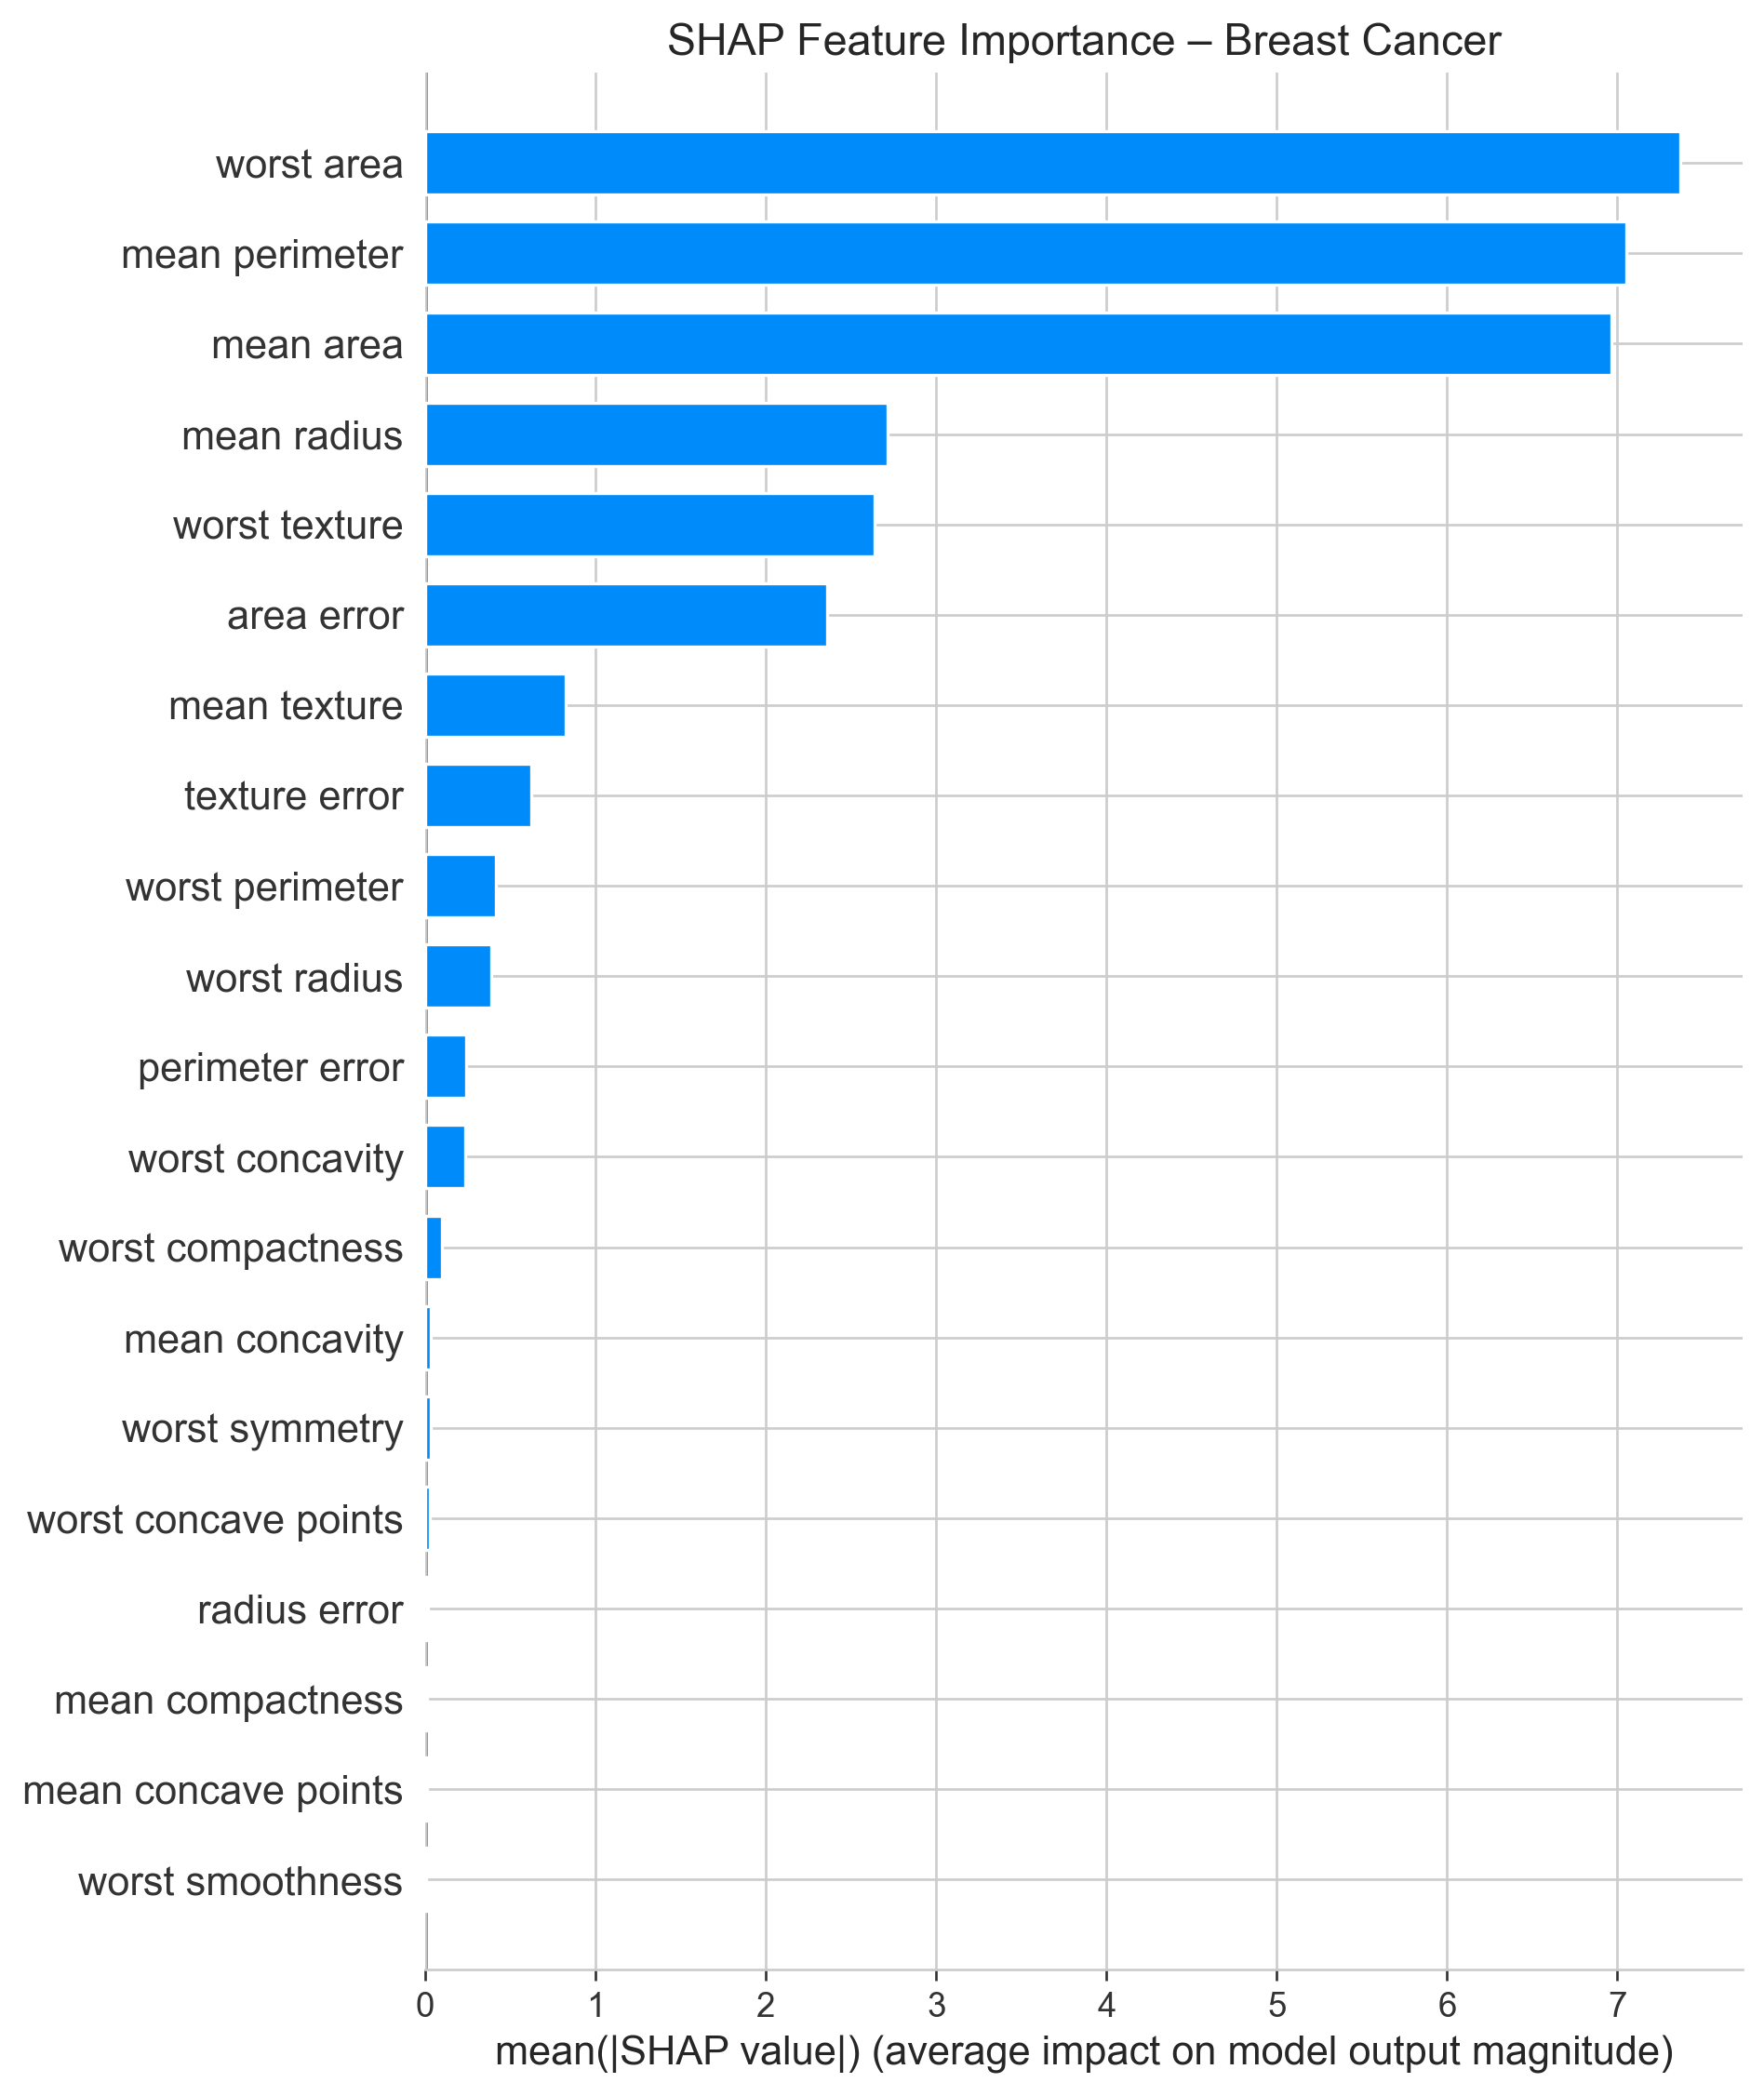

<Figure size 768x576 with 0 Axes>

In [12]:
# %% SHAP Explainer
explainer = shap.Explainer(model_lr, X_train, feature_names=feature_names)
shap_values = explainer.shap_values(X_test)

# Global summary plot
plt.title('SHAP Summary Plot – Breast Cancer')
shap.summary_plot(shap_values, X_test, feature_names=feature_names)
plt.savefig('plots/shap_summary_breast_cancer.png', dpi=300)
plt.tight_layout()
plt.show()

# Bar plot (mean absolute SHAP values)
plt.title('SHAP Feature Importance – Breast Cancer')
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar')
plt.savefig('plots/shap_importance_breast_cancer.png', dpi=300)
plt.tight_layout()
plt.show()

### 1.2 Local Interpretation

We explain individual predictions using waterfall and force plots.

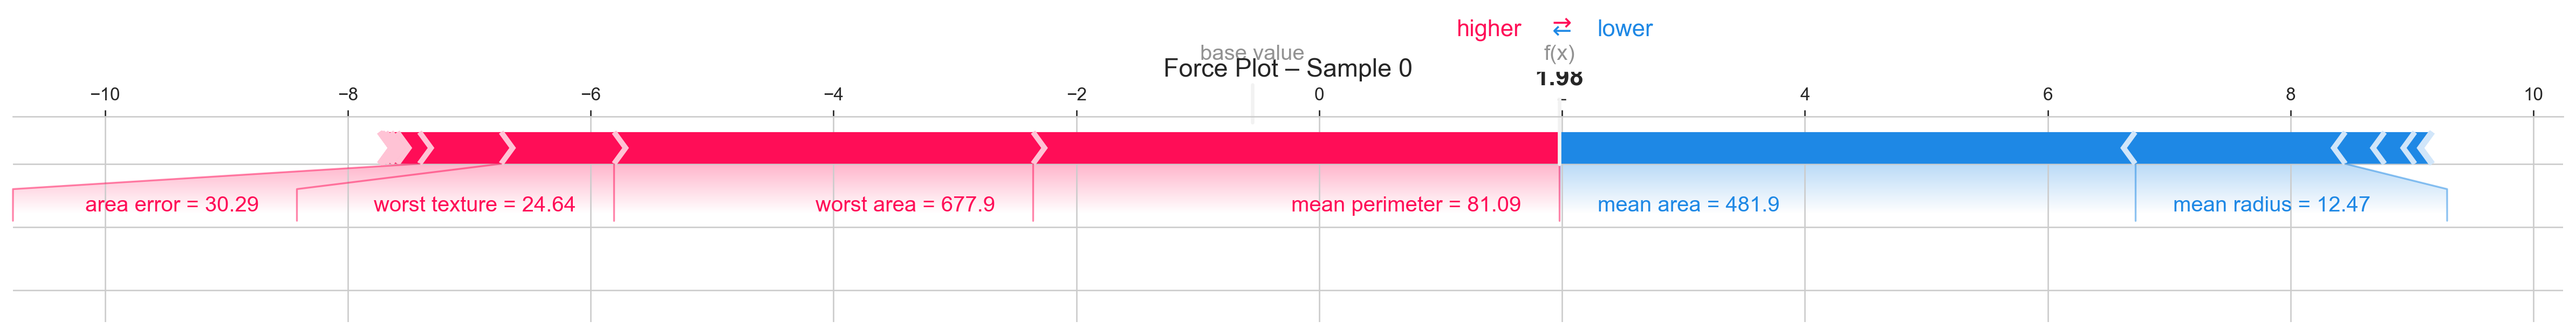

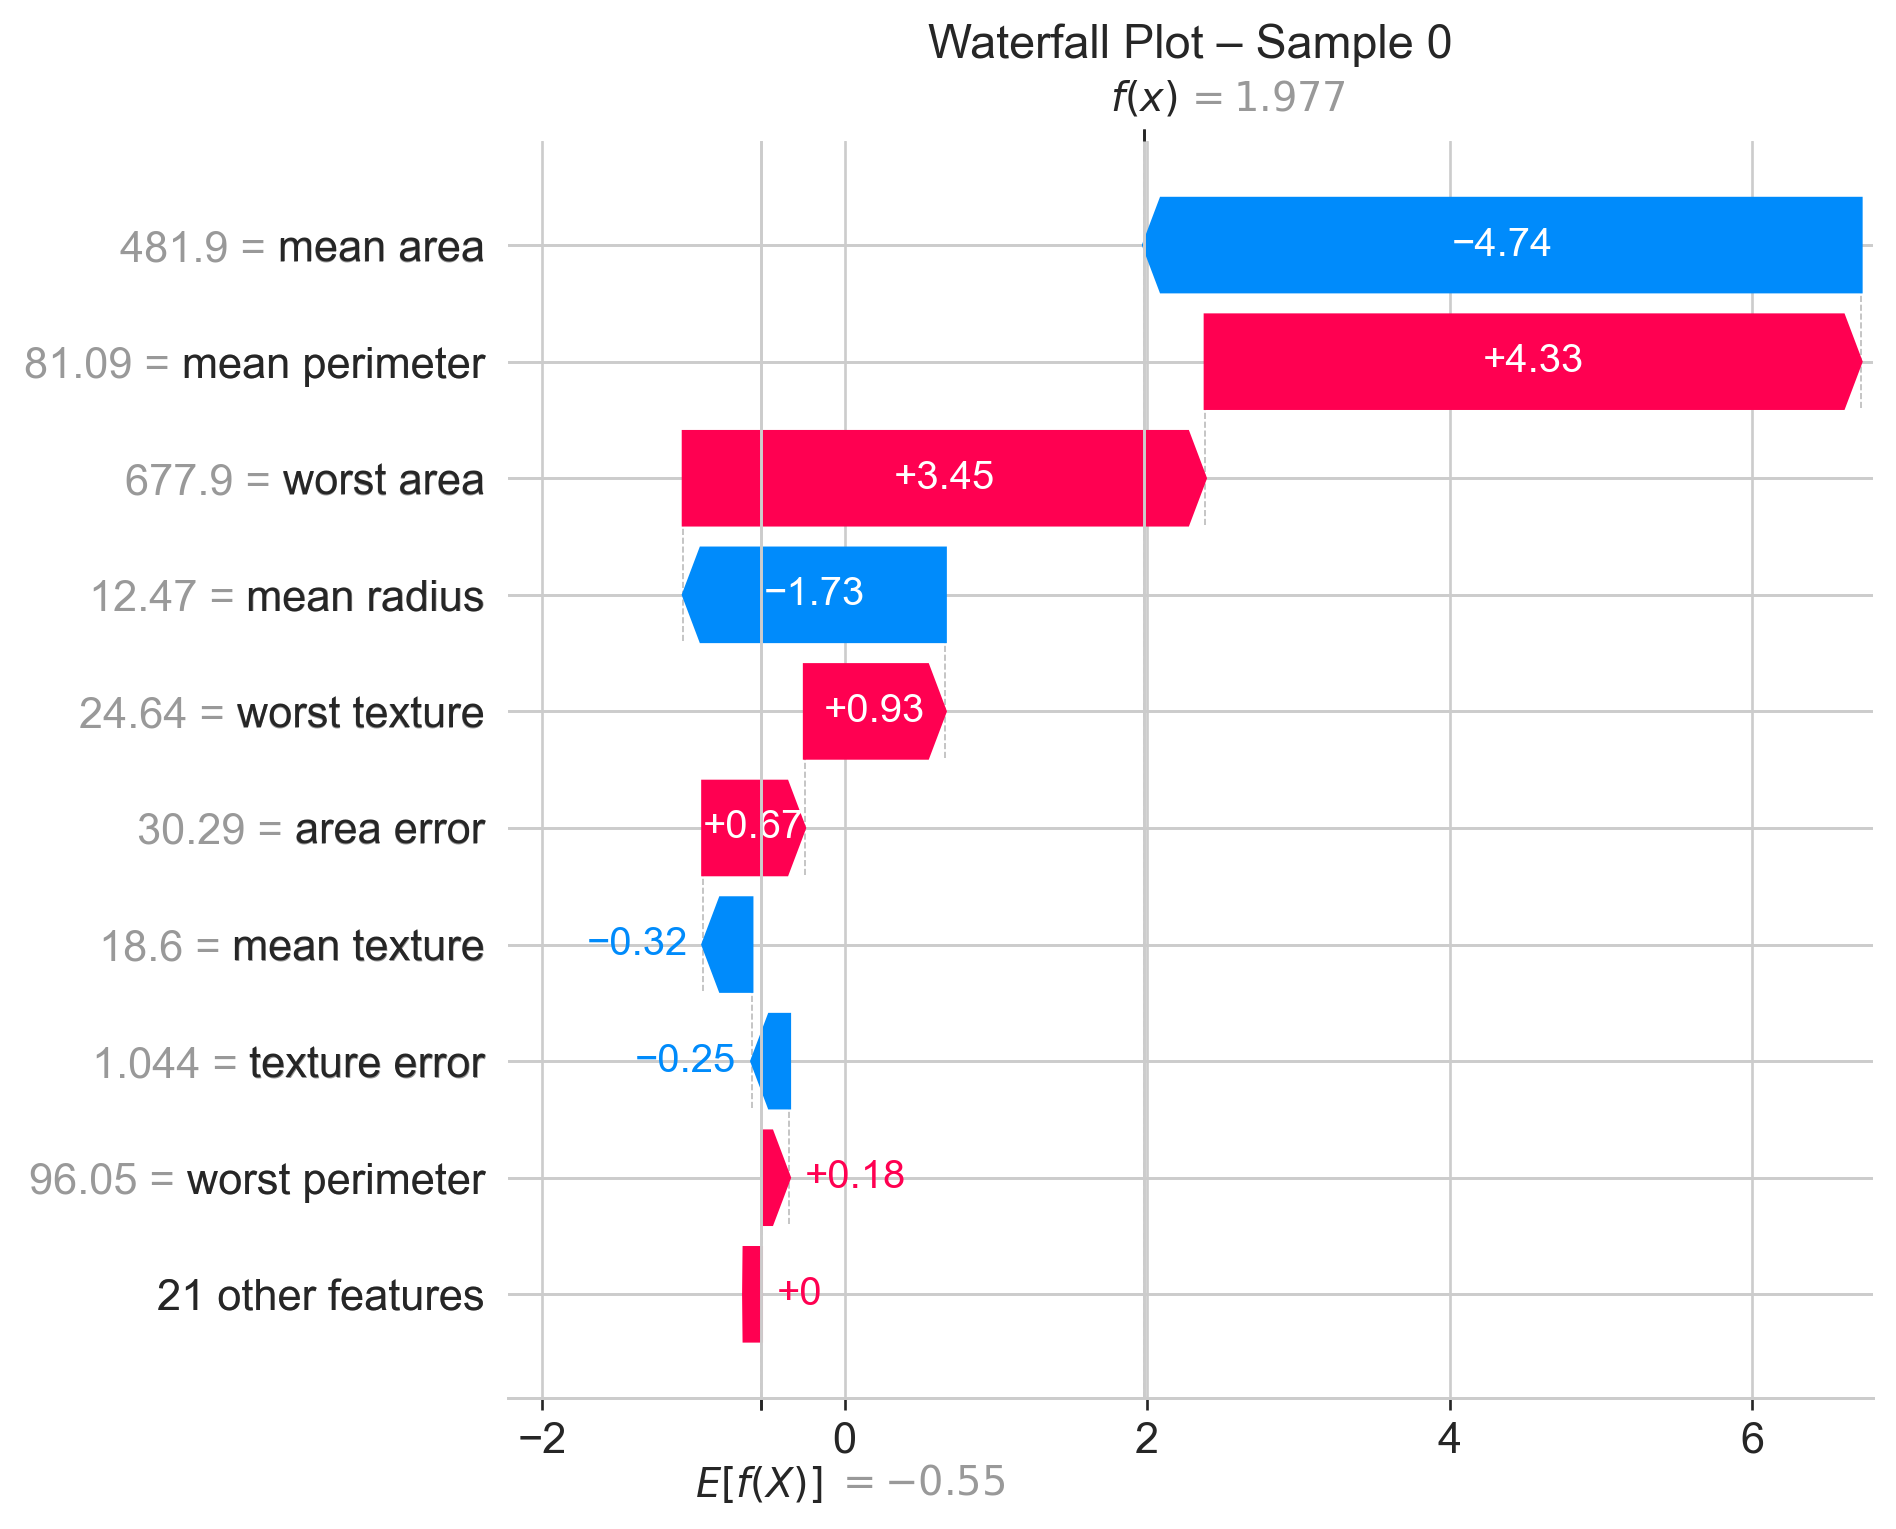

In [19]:
# %% Individual Prediction Explanation – Force & Waterfall Plots
idx = 0

# ---- Force Plot ----
# Extract SHAP values for this sample
if hasattr(shap_values, 'values'):
    sv = shap_values[idx].values
else:
    sv = shap_values[idx]

# Handle base value
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

shap.initjs()
force_plot = shap.force_plot(
    base_val,
    sv,
    X_test[idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot – Sample {idx}')
plt.tight_layout()
plt.savefig(f'plots/force_sample_{idx}.png', dpi=300)
plt.show()

# ---- Waterfall Plot ----
# Create an Explanation object if needed
def get_explanation(shap_values, base_value, data, feature_names):
    """Convert SHAP values to Explanation object for waterfall."""
    if isinstance(shap_values, shap.Explanation):
        return shap_values
    # Build Explanation object
    return shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=data,
        feature_names=feature_names
    )

explanation = get_explanation(shap_values, base_val, X_test, feature_names)
# Take the selected sample
explanation_sample = explanation[idx]

shap.plots.waterfall(explanation_sample, max_display=10, show=False)
plt.title(f'Waterfall Plot – Sample {idx}')
plt.tight_layout()
plt.savefig(f'plots/waterfall_sample_{idx}.png', dpi=300)
plt.show()

# Part II: Loan Approval Dataset – Logistic Regression & Decision Tree

We apply SHAP to a more complex dataset with mixed data types (categorical and numerical) to demonstrate SHAP's versatility.

In [20]:
# %% Data Loading
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"
df = pd.read_csv(url, index_col=0)

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Drop irrelevant columns
df.drop(columns=["Loan_ID", "Property_Area"], inplace=True)

# Encode categorical variables
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})

# Drop rows with missing values
df.dropna(inplace=True)

X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

print(f"Preprocessed dataset shape: {df.shape}")
print("\nClass distribution:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Dataset shape: (491, 13)

First 5 rows:
    Loan_ID  Gender Married Dependents     Education Self_Employed  \
0  LP002305  Female      No          0      Graduate            No   
1  LP001715    Male     Yes         3+  Not Graduate           Yes   
2  LP002086  Female     Yes          0      Graduate            No   
3  LP001136    Male     Yes          0  Not Graduate           Yes   
4  LP002529    Male     Yes          2      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4547                0.0       115.0             360.0   
1             5703                0.0       130.0             360.0   
2             4333             2451.0       110.0             360.0   
3             4695                0.0        96.0               NaN   
4             6700             1750.0       230.0             300.0   

   Credit_History Property_Area  Loan_Status  
0             1.0     Semiurban            1  
1             1.0 

### 2.1 Logistic Regression


=== Logistic Regression (Loan) ===
              precision    recall  f1-score   support

           0       0.86      0.27      0.41        22
           1       0.77      0.98      0.86        55

    accuracy                           0.78        77
   macro avg       0.81      0.63      0.64        77
weighted avg       0.80      0.78      0.74        77



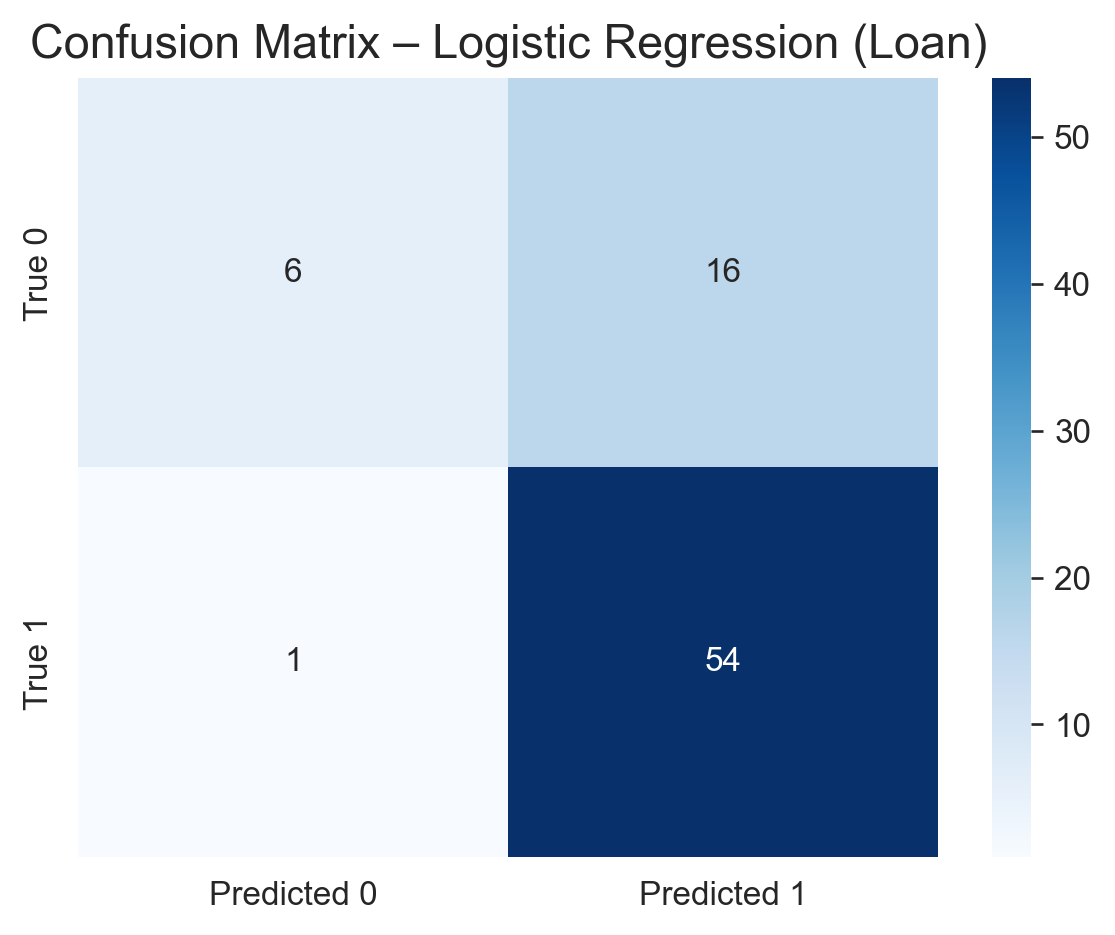

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [21]:
# %% Logistic Regression
model_lr_loan = LogisticRegression(max_iter=3000, random_state=42)
model_lr_loan.fit(X_train, y_train)
evaluate_model(model_lr_loan, X_test, y_test, 'Logistic Regression (Loan)')

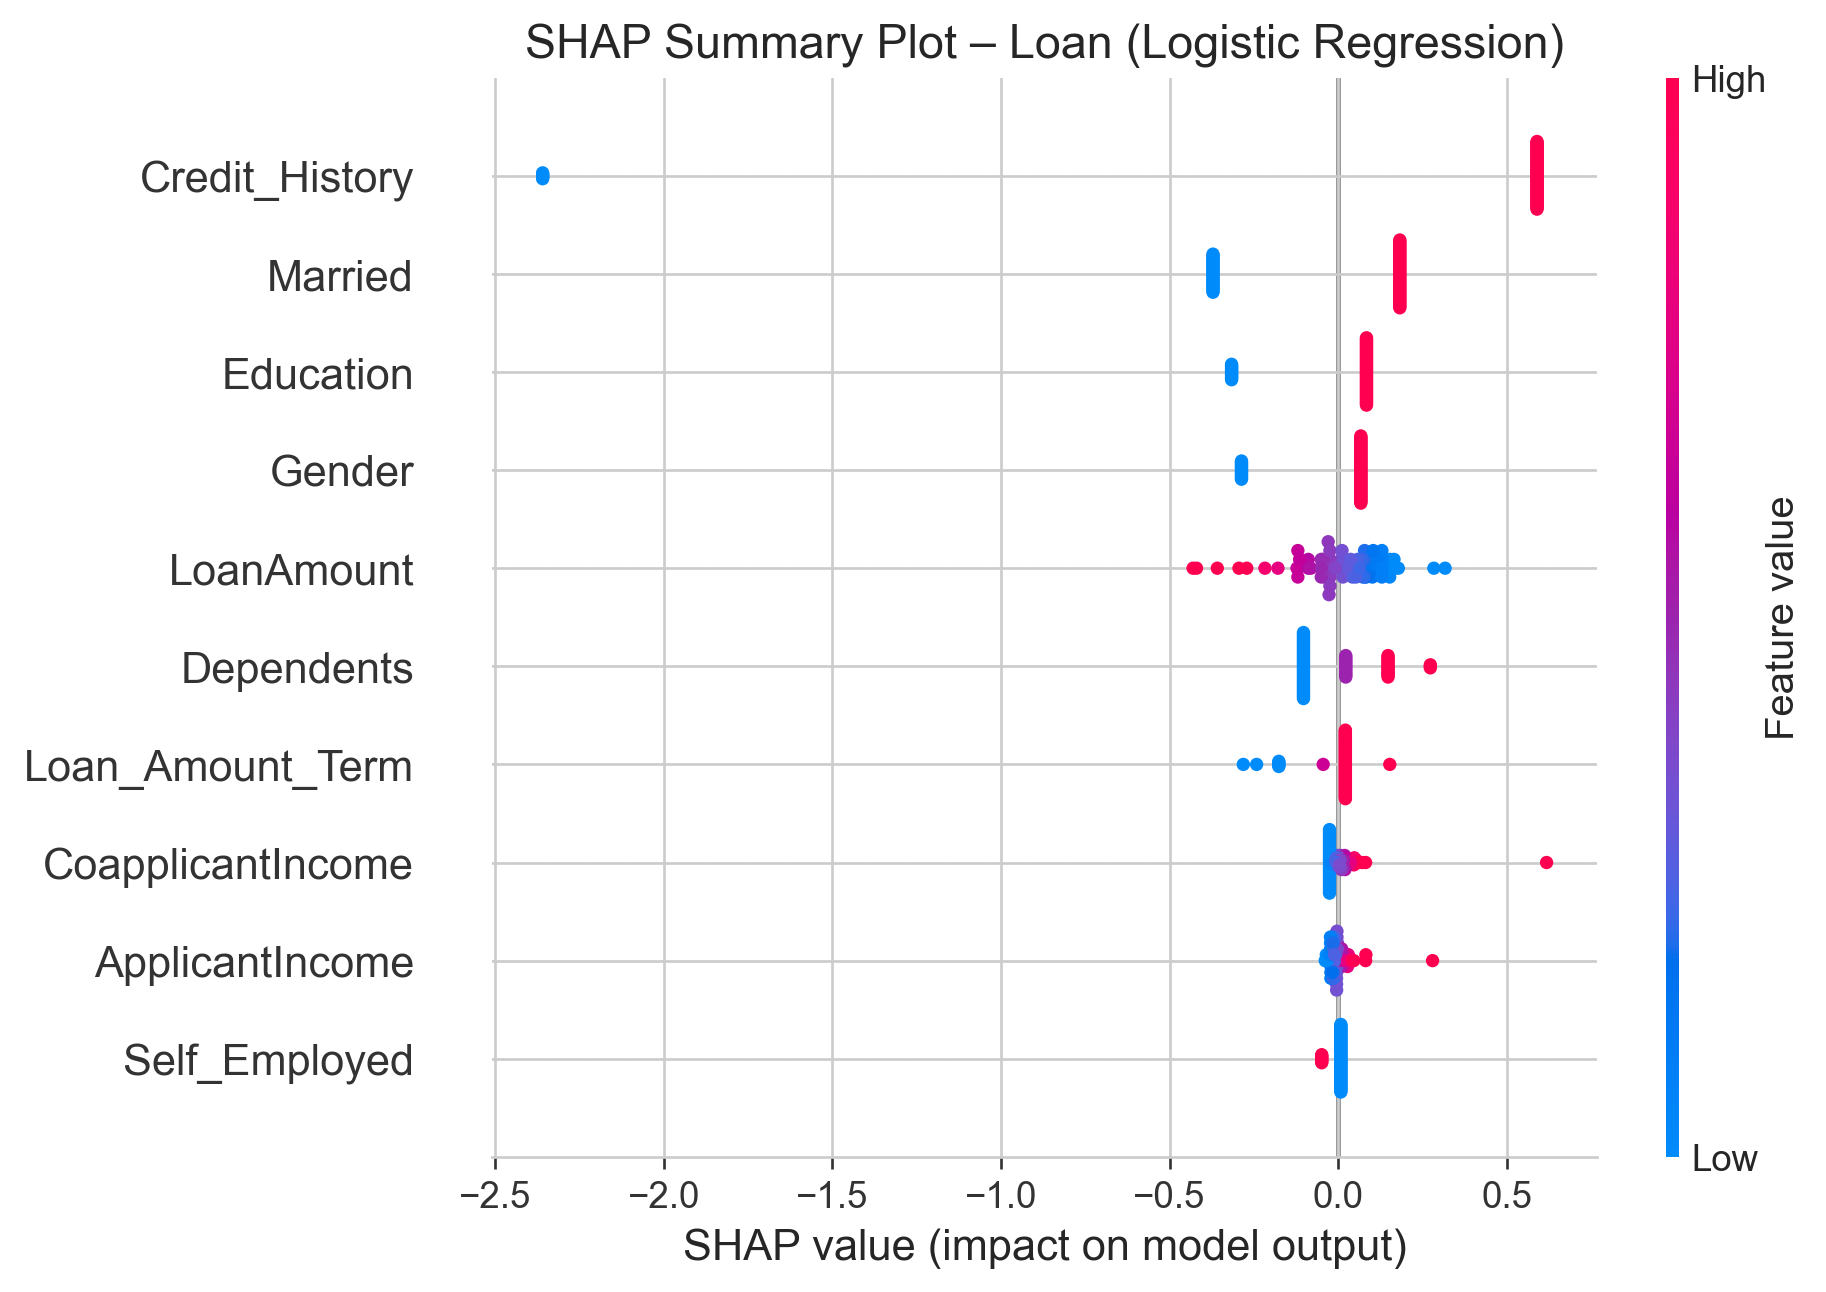

<Figure size 768x576 with 0 Axes>

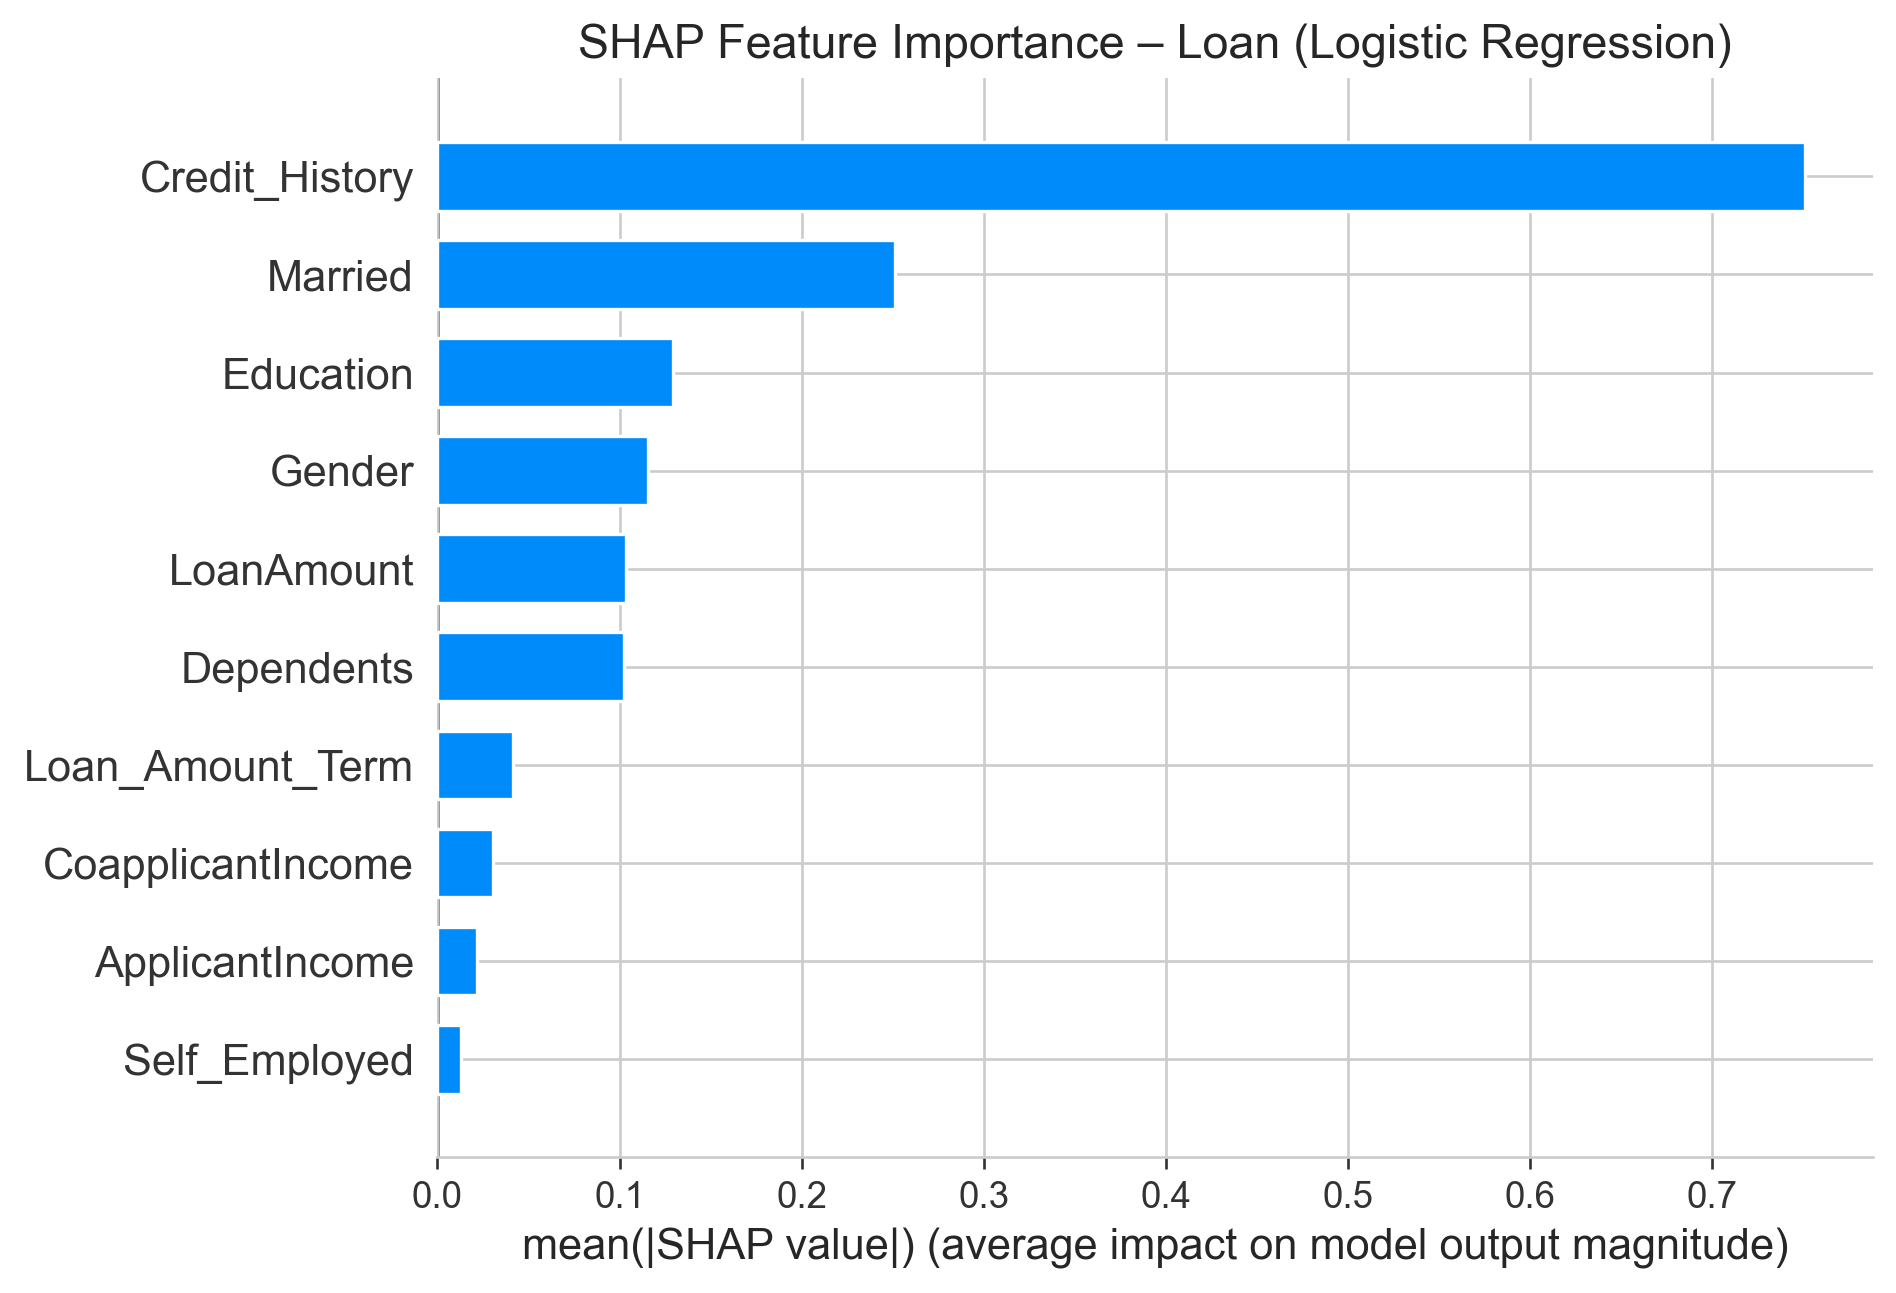

<Figure size 768x576 with 0 Axes>

In [23]:
# %% SHAP for Logistic Regression
explainer_lr_loan = shap.Explainer(model_lr_loan, X_train)
shap_values_lr_loan = explainer_lr_loan.shap_values(X_test)

# Summary plot
plt.title('SHAP Summary Plot – Loan (Logistic Regression)')
shap.summary_plot(shap_values_lr_loan, X_test, feature_names=X.columns)
plt.tight_layout()
plt.savefig('plots/shap_summary_loan_lr.png', dpi=300)
plt.show()

# Bar plot
plt.title('SHAP Feature Importance – Loan (Logistic Regression)')
shap.summary_plot(shap_values_lr_loan, X_test, feature_names=X.columns, plot_type='bar')
plt.tight_layout()
plt.savefig('plots/shap_importance_loan_lr.png', dpi=300)
plt.show()

### 2.2 Decision Tree

We also train a decision tree to compare SHAP explanations between linear and non‑linear models.


=== Decision Tree (Loan) ===
              precision    recall  f1-score   support

           0       0.60      0.27      0.38        22
           1       0.76      0.93      0.84        55

    accuracy                           0.74        77
   macro avg       0.68      0.60      0.61        77
weighted avg       0.72      0.74      0.70        77



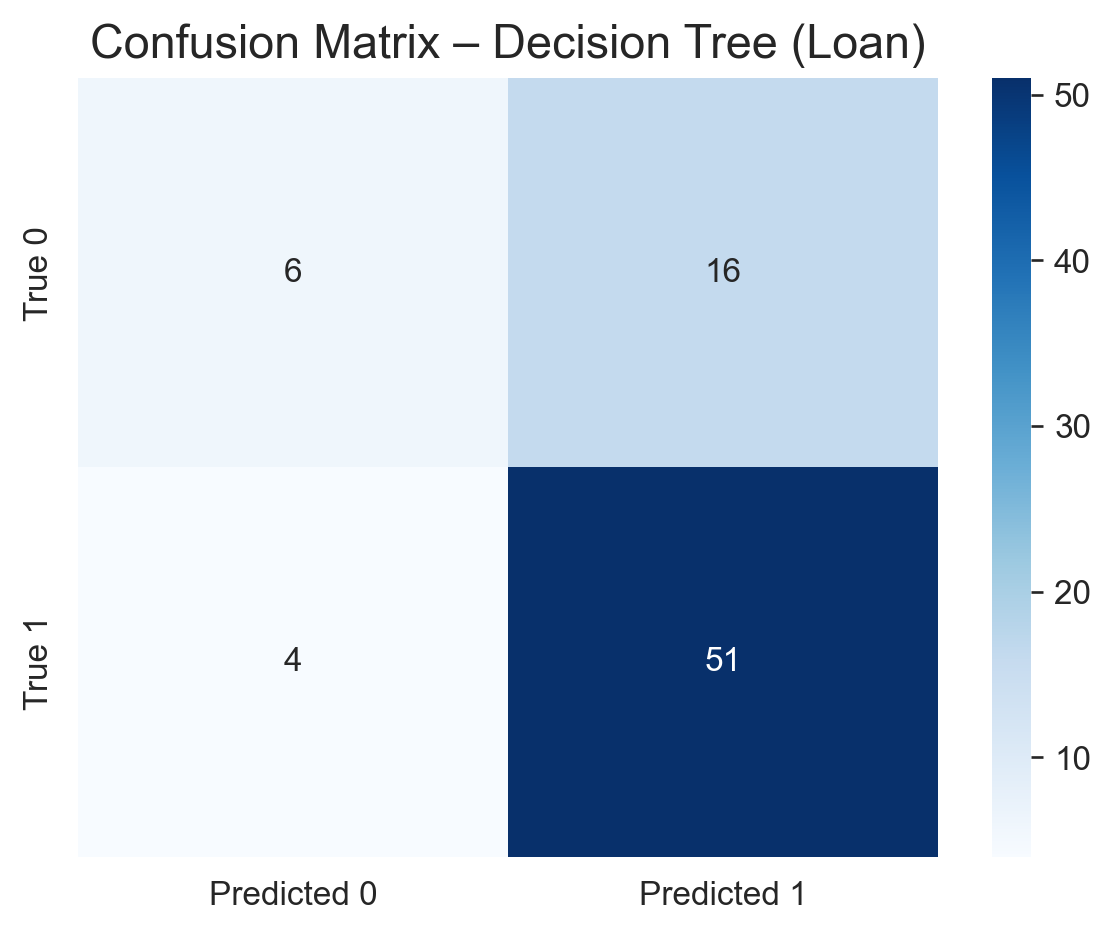

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1])

In [24]:
# %% Decision Tree
model_dt_loan = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt_loan.fit(X_train, y_train)
evaluate_model(model_dt_loan, X_test, y_test, 'Decision Tree (Loan)')

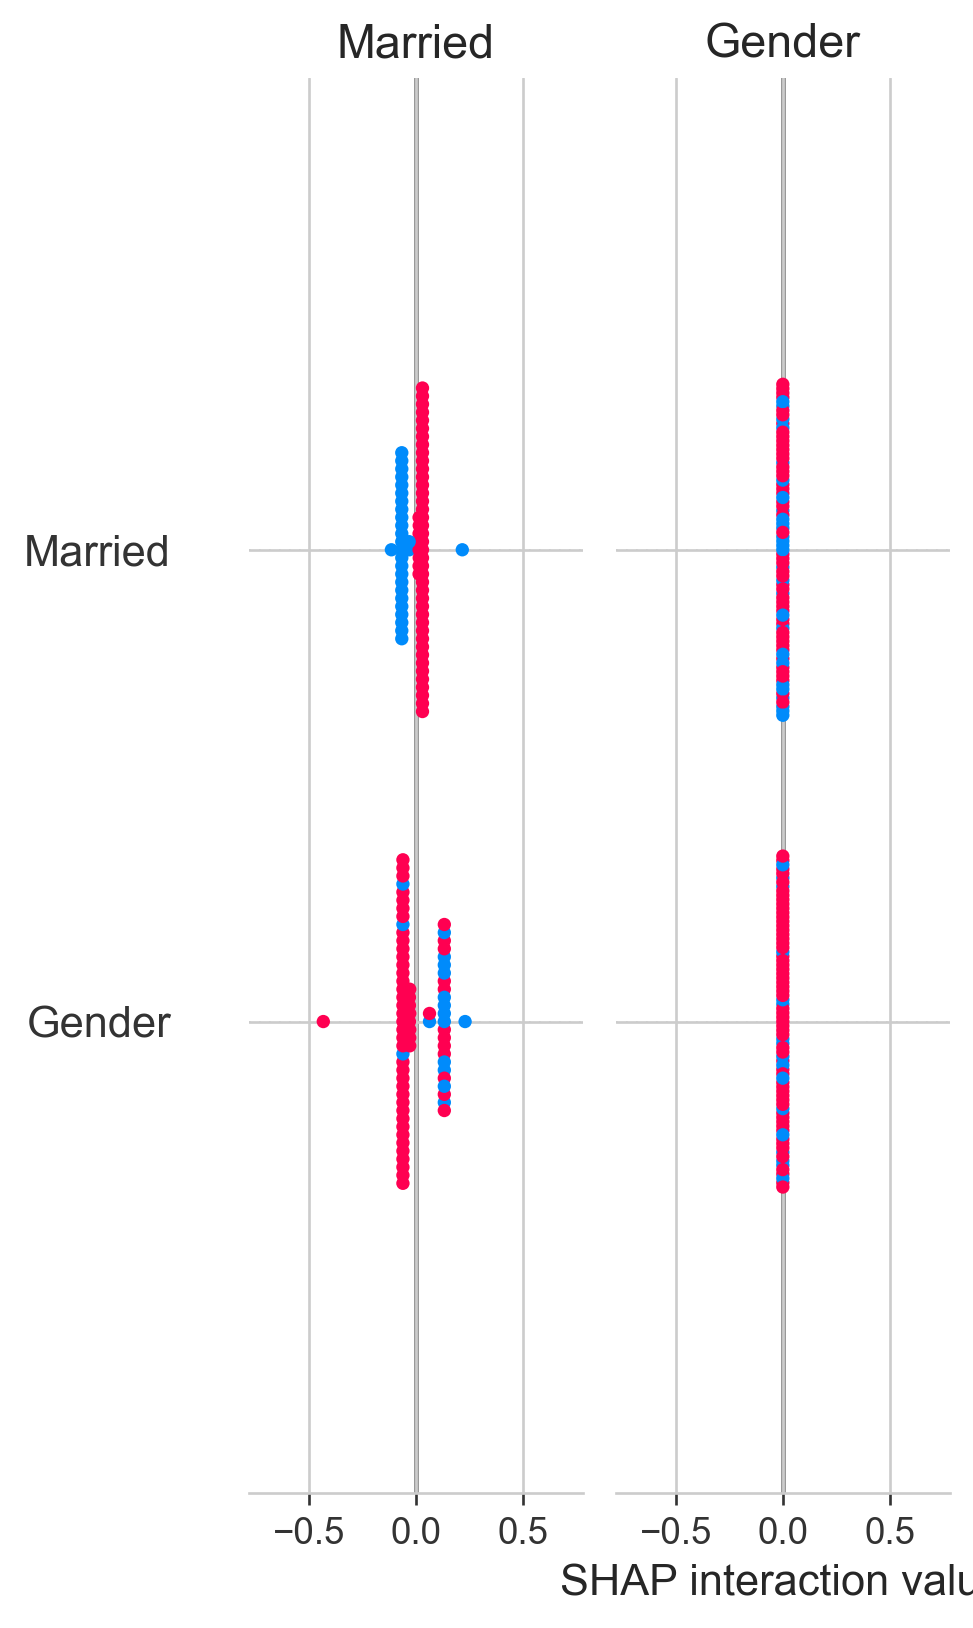

<Figure size 768x576 with 0 Axes>

In [31]:
# %% SHAP for Decision Tree
# For tree‑based models, use TreeExplainer (faster and more accurate)
explainer_dt_loan = shap.TreeExplainer(model_dt_loan)
shap_values_dt_loan = explainer_dt_loan.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values_dt_loan, X_test, feature_names=X.columns)
#plt.title('SHAP Summary Plot – Loan (Decision Tree)')
plt.tight_layout()
plt.savefig('plots/shap_summary_loan_dt.png', dpi=300)
plt.show()

### 2.3 Dependence Plots

Dependence plots show how the SHAP value for a feature changes as the feature's value changes, revealing interactions.

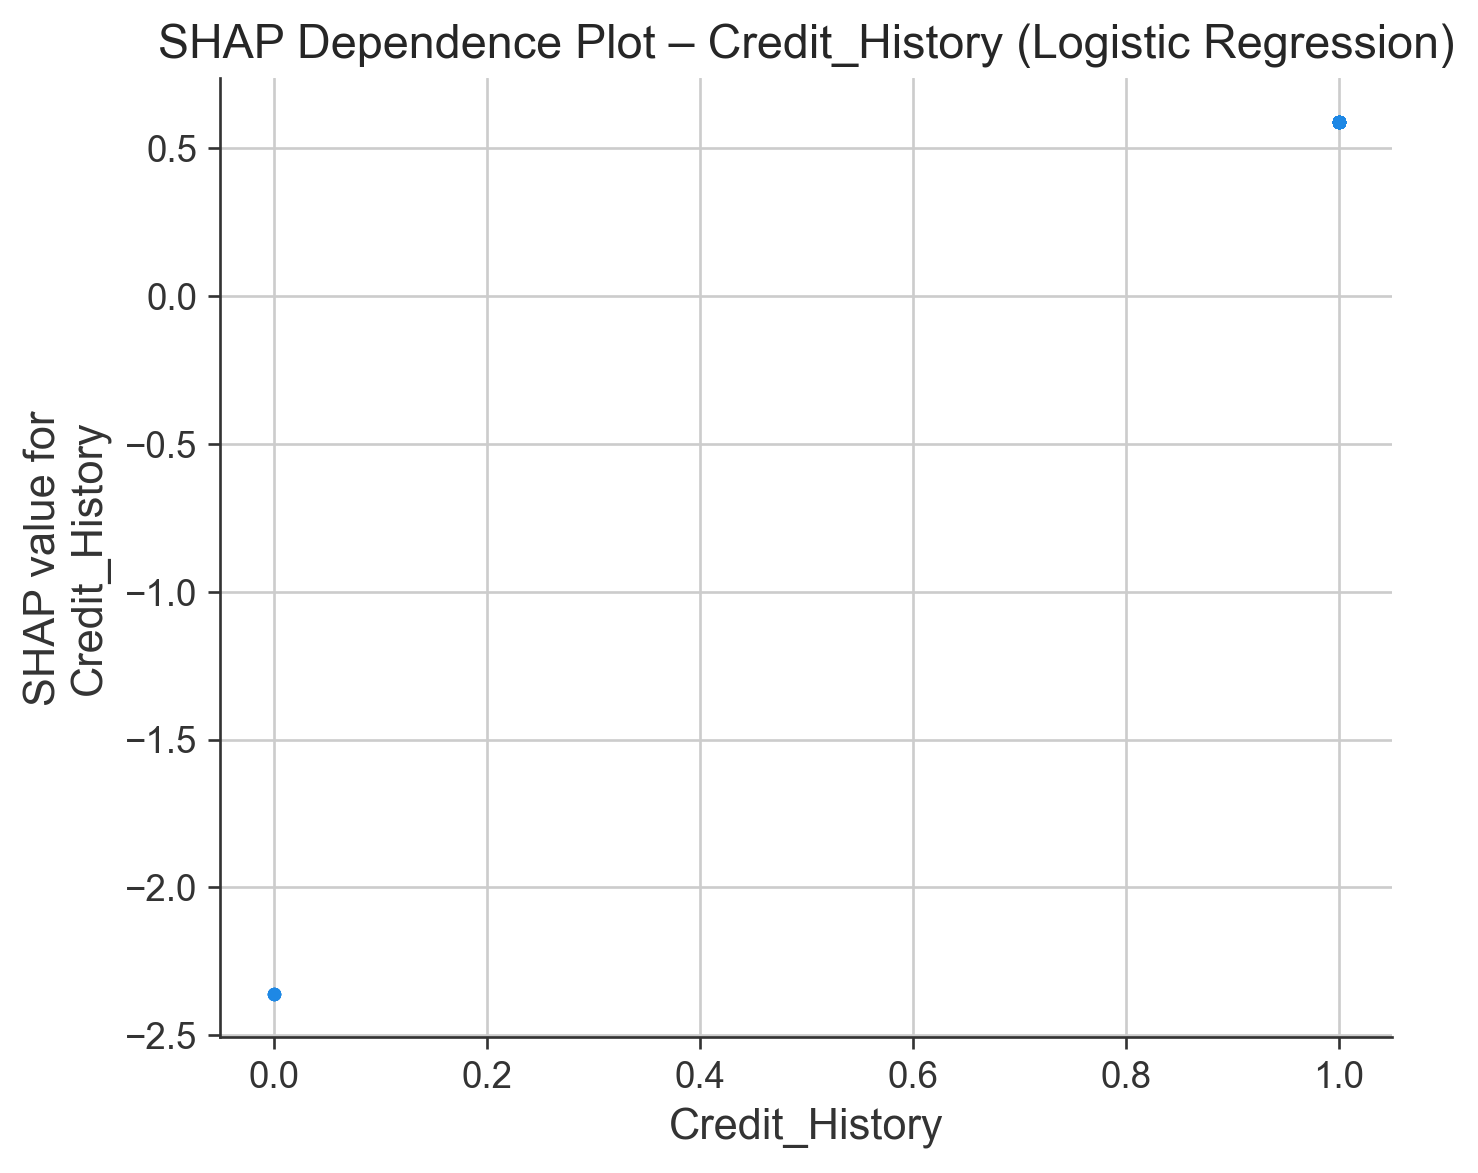

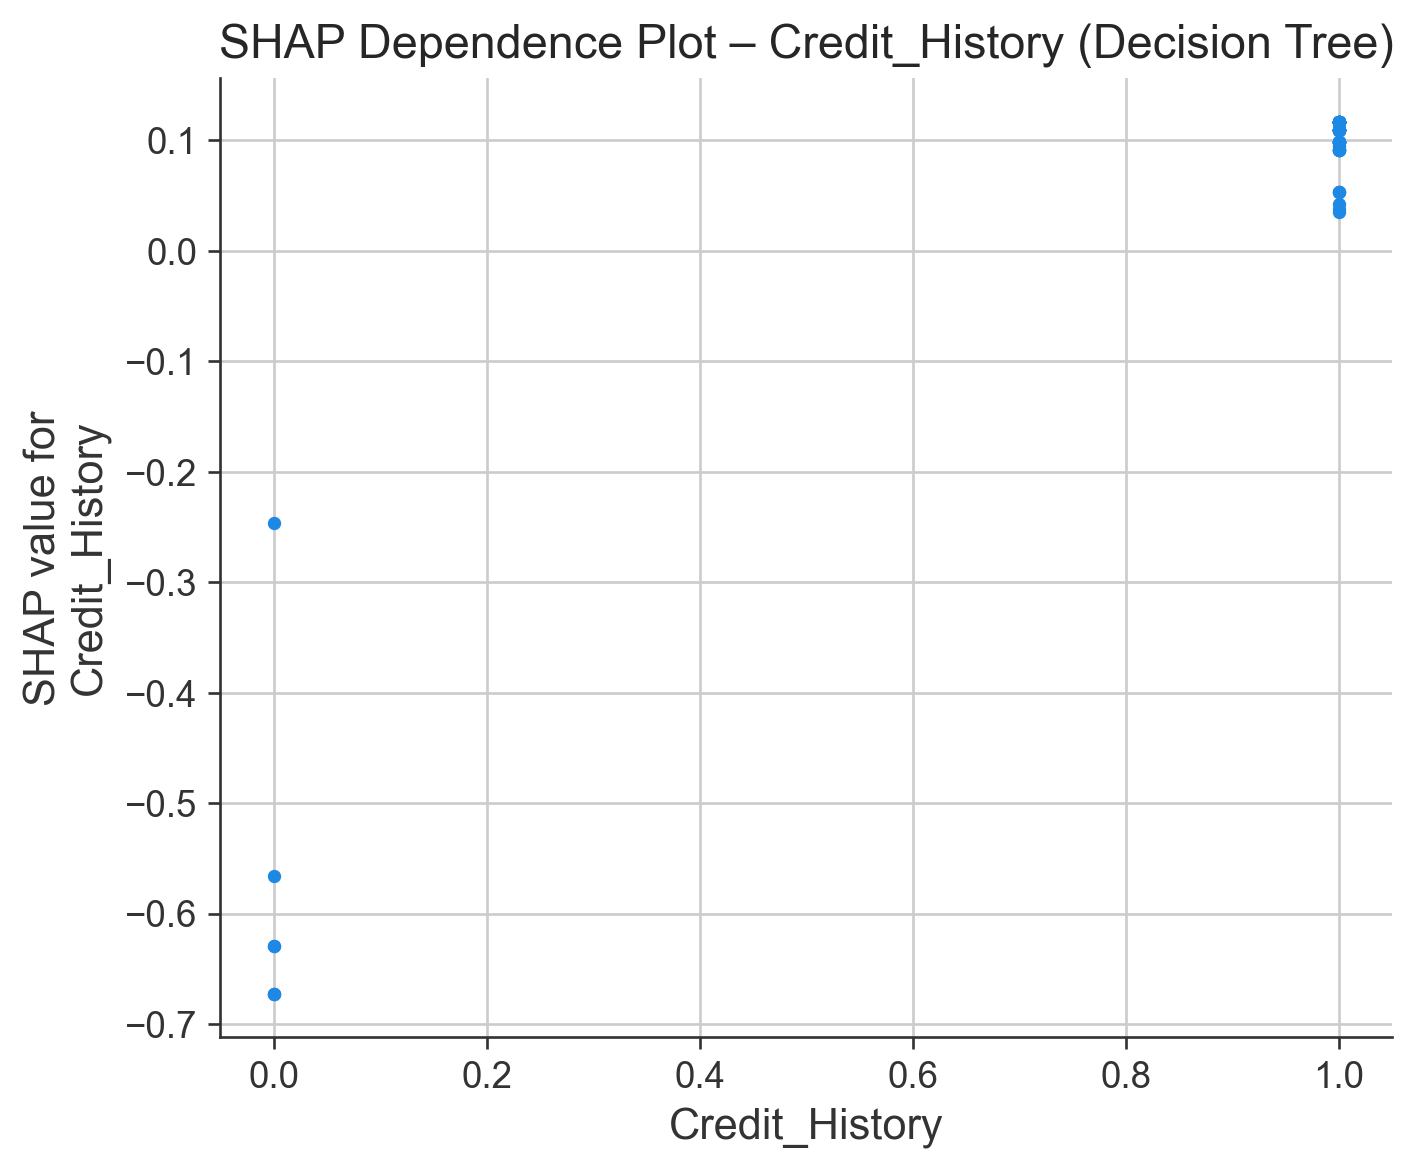

In [36]:
# %% Dependence Plots – Logistic Regression & Decision Tree
# Use dependence_plot with interaction_index=None to avoid corrcoef error

def get_shap_array(shap_values):
    """Extract a 2D SHAP array (positive class) from any SHAP object."""
    if hasattr(shap_values, 'values'):
        arr = shap_values.values
    else:
        arr = shap_values
    # For binary classification, shap_values can be 3D (n_samples, n_features, 2)
    # We want the positive class (index 1)
    if len(arr.shape) == 3:
        arr = arr[:, :, 1]
    return arr

# Prepare data
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
feature_names = X.columns.tolist()

# Get the column index for "Credit_History"
if "Credit_History" in feature_names:
    idx_credit = feature_names.index("Credit_History")
else:
    # Fallback: try to find by matching
    for i, name in enumerate(feature_names):
        if name.lower().replace("_", " ").strip() == "credit history":
            idx_credit = i
            break
    else:
        idx_credit = 0
        print("Warning: 'Credit_History' not found; using first feature.")

# ---- Logistic Regression ----
shap_arr_lr = get_shap_array(shap_values_lr_loan)
shap.dependence_plot(
    idx_credit,
    shap_arr_lr,
    X_test_np,
    feature_names=feature_names,
    interaction_index=None,  # prevents auto‑computation that caused the error
    show=False
)
plt.title('SHAP Dependence Plot – Credit_History (Logistic Regression)')
plt.tight_layout()
plt.savefig('plots/dependence_credit_history_lr.png', dpi=300)
plt.show()

# ---- Decision Tree ----
shap_arr_dt = get_shap_array(shap_values_dt_loan)
shap.dependence_plot(
    idx_credit,
    shap_arr_dt,
    X_test_np,
    feature_names=feature_names,
    interaction_index=None,
    show=False
)
plt.title('SHAP Dependence Plot – Credit_History (Decision Tree)')
plt.tight_layout()
plt.savefig('plots/dependence_credit_history_dt.png', dpi=300)
plt.show()

### 2.4 Individual Predictions

We explain a single prediction from the logistic regression model using a waterfall plot.

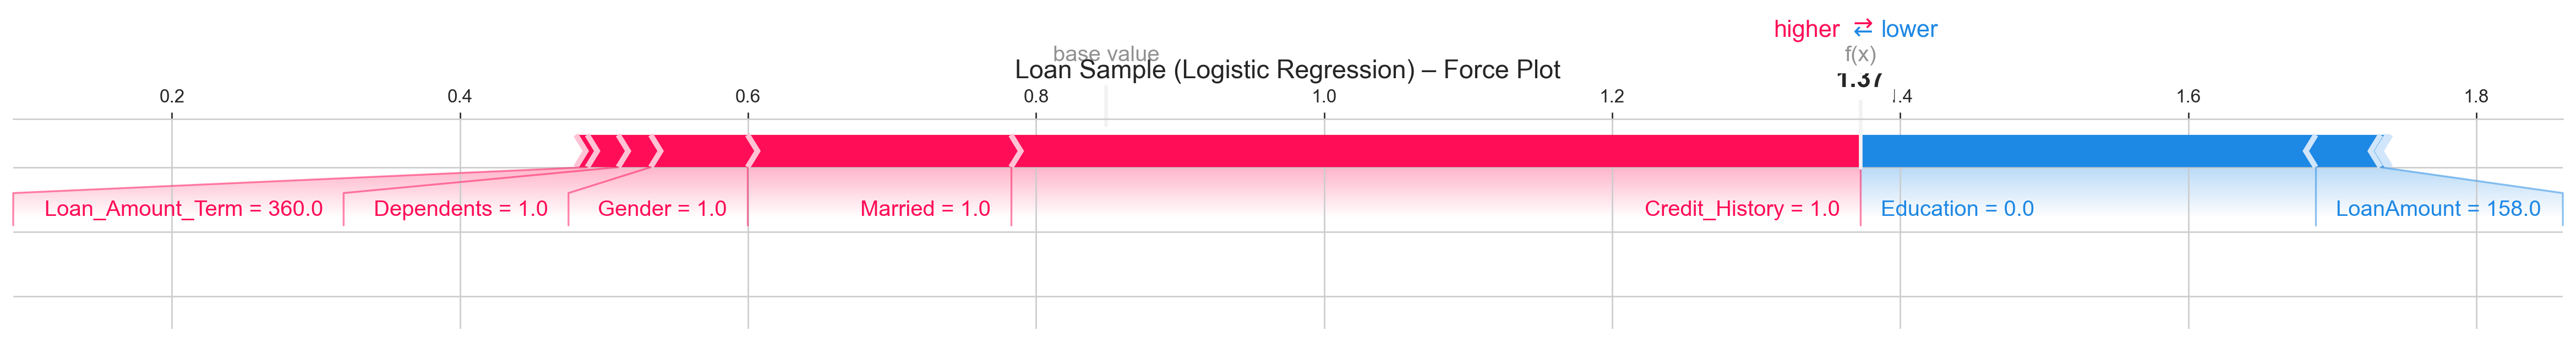

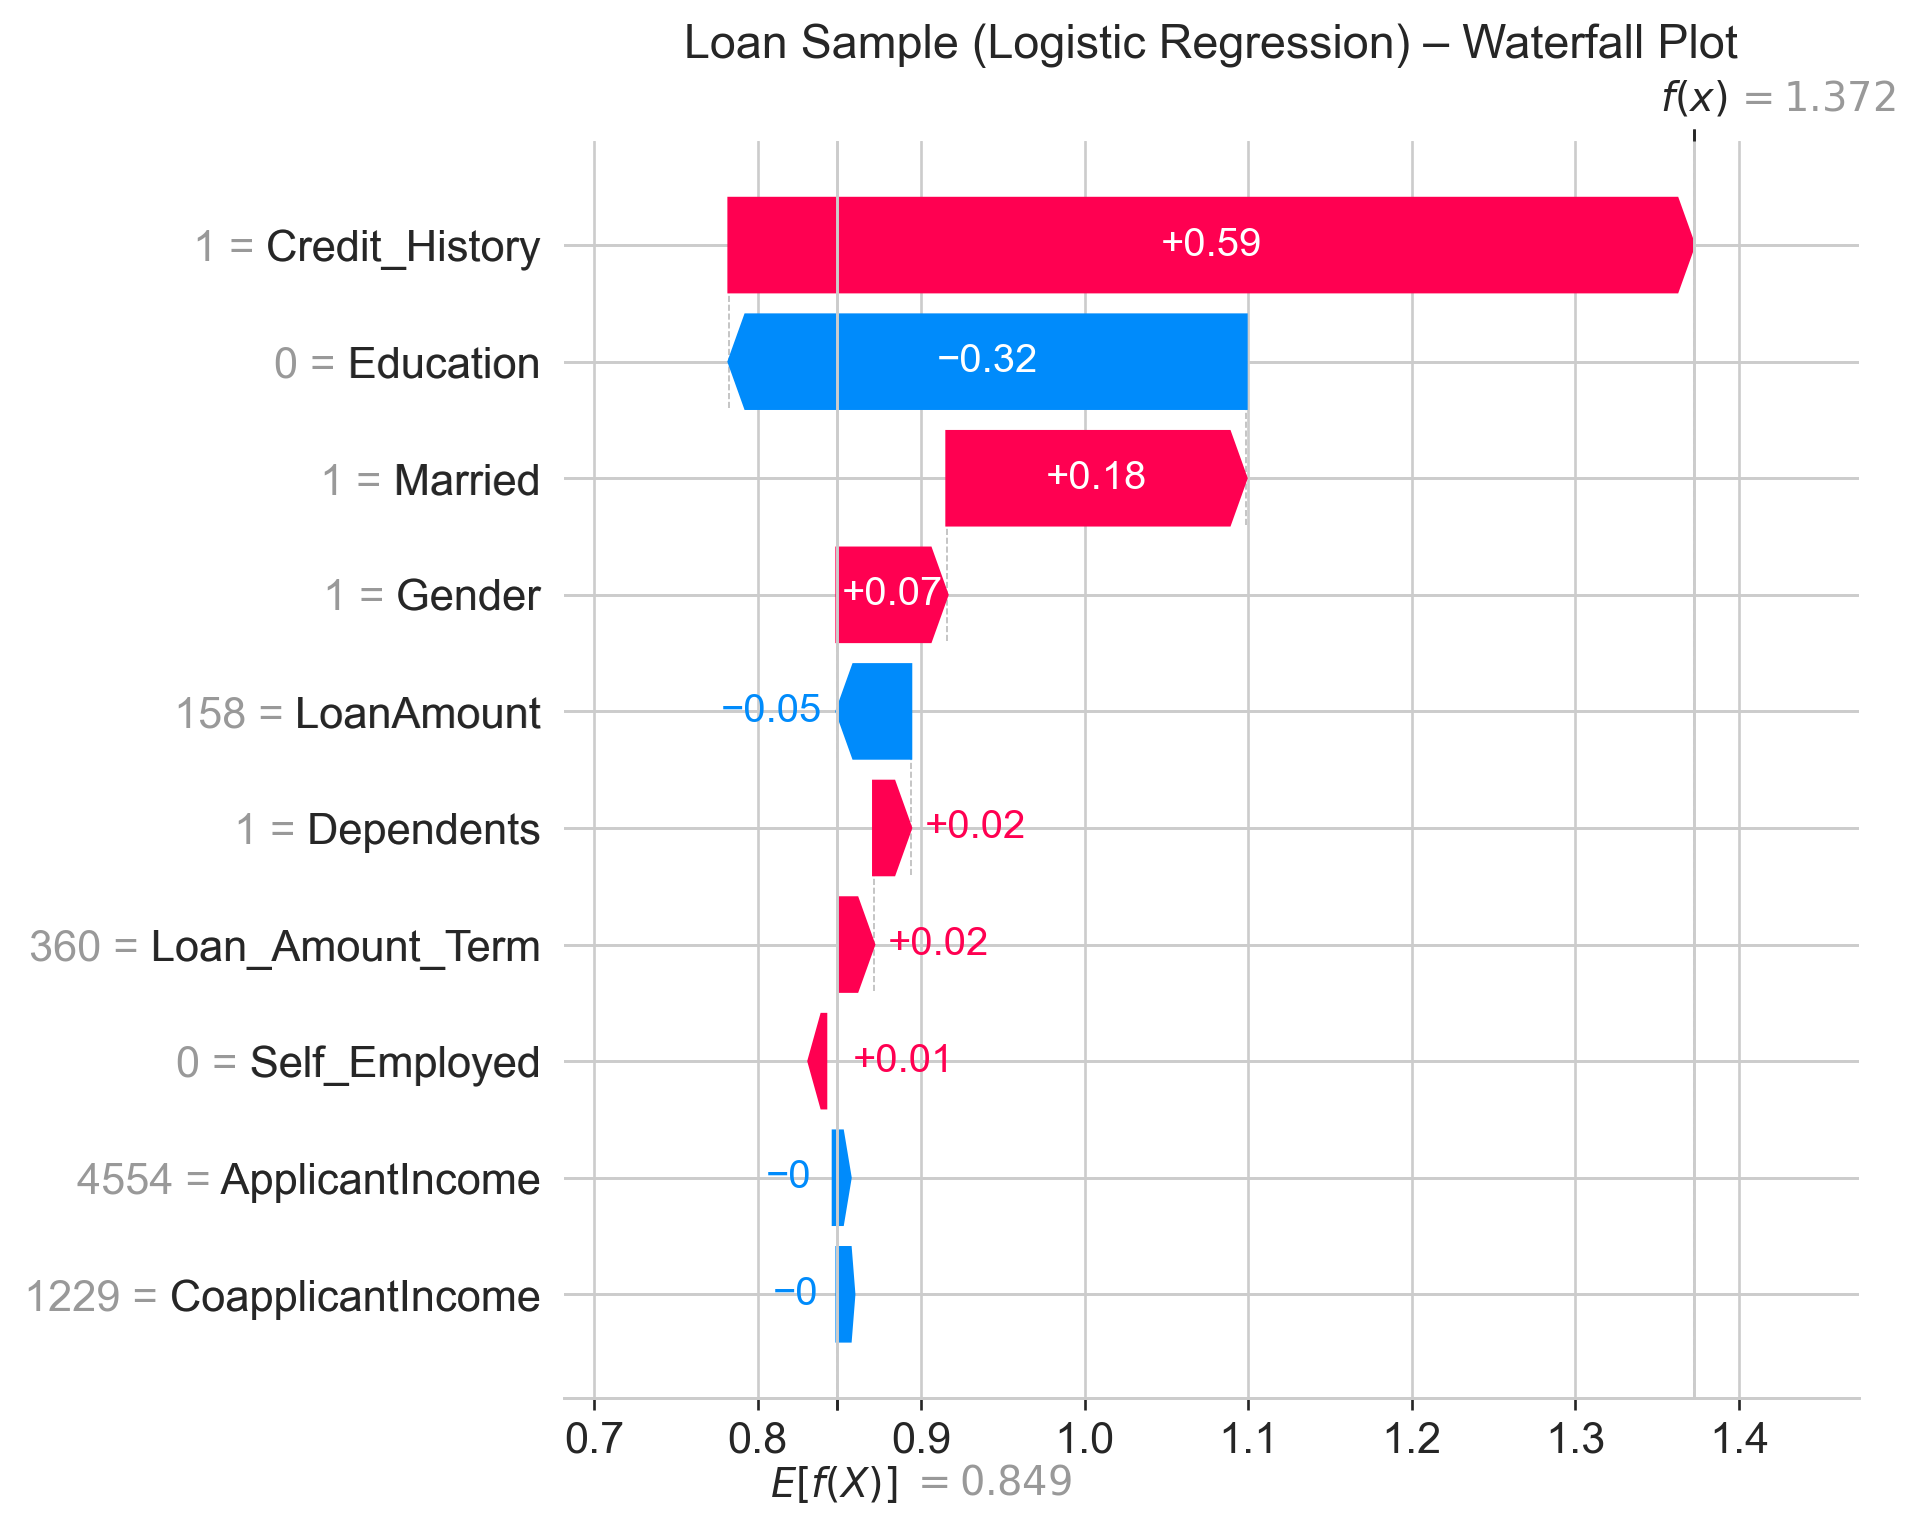

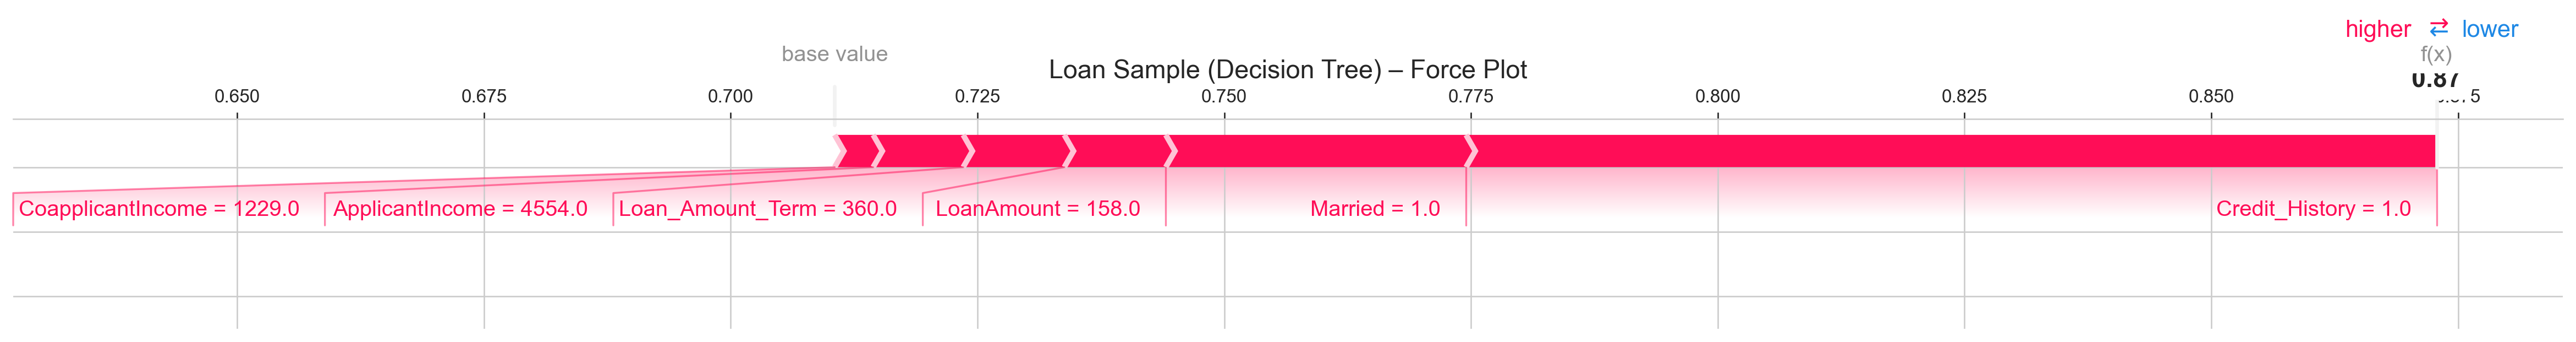

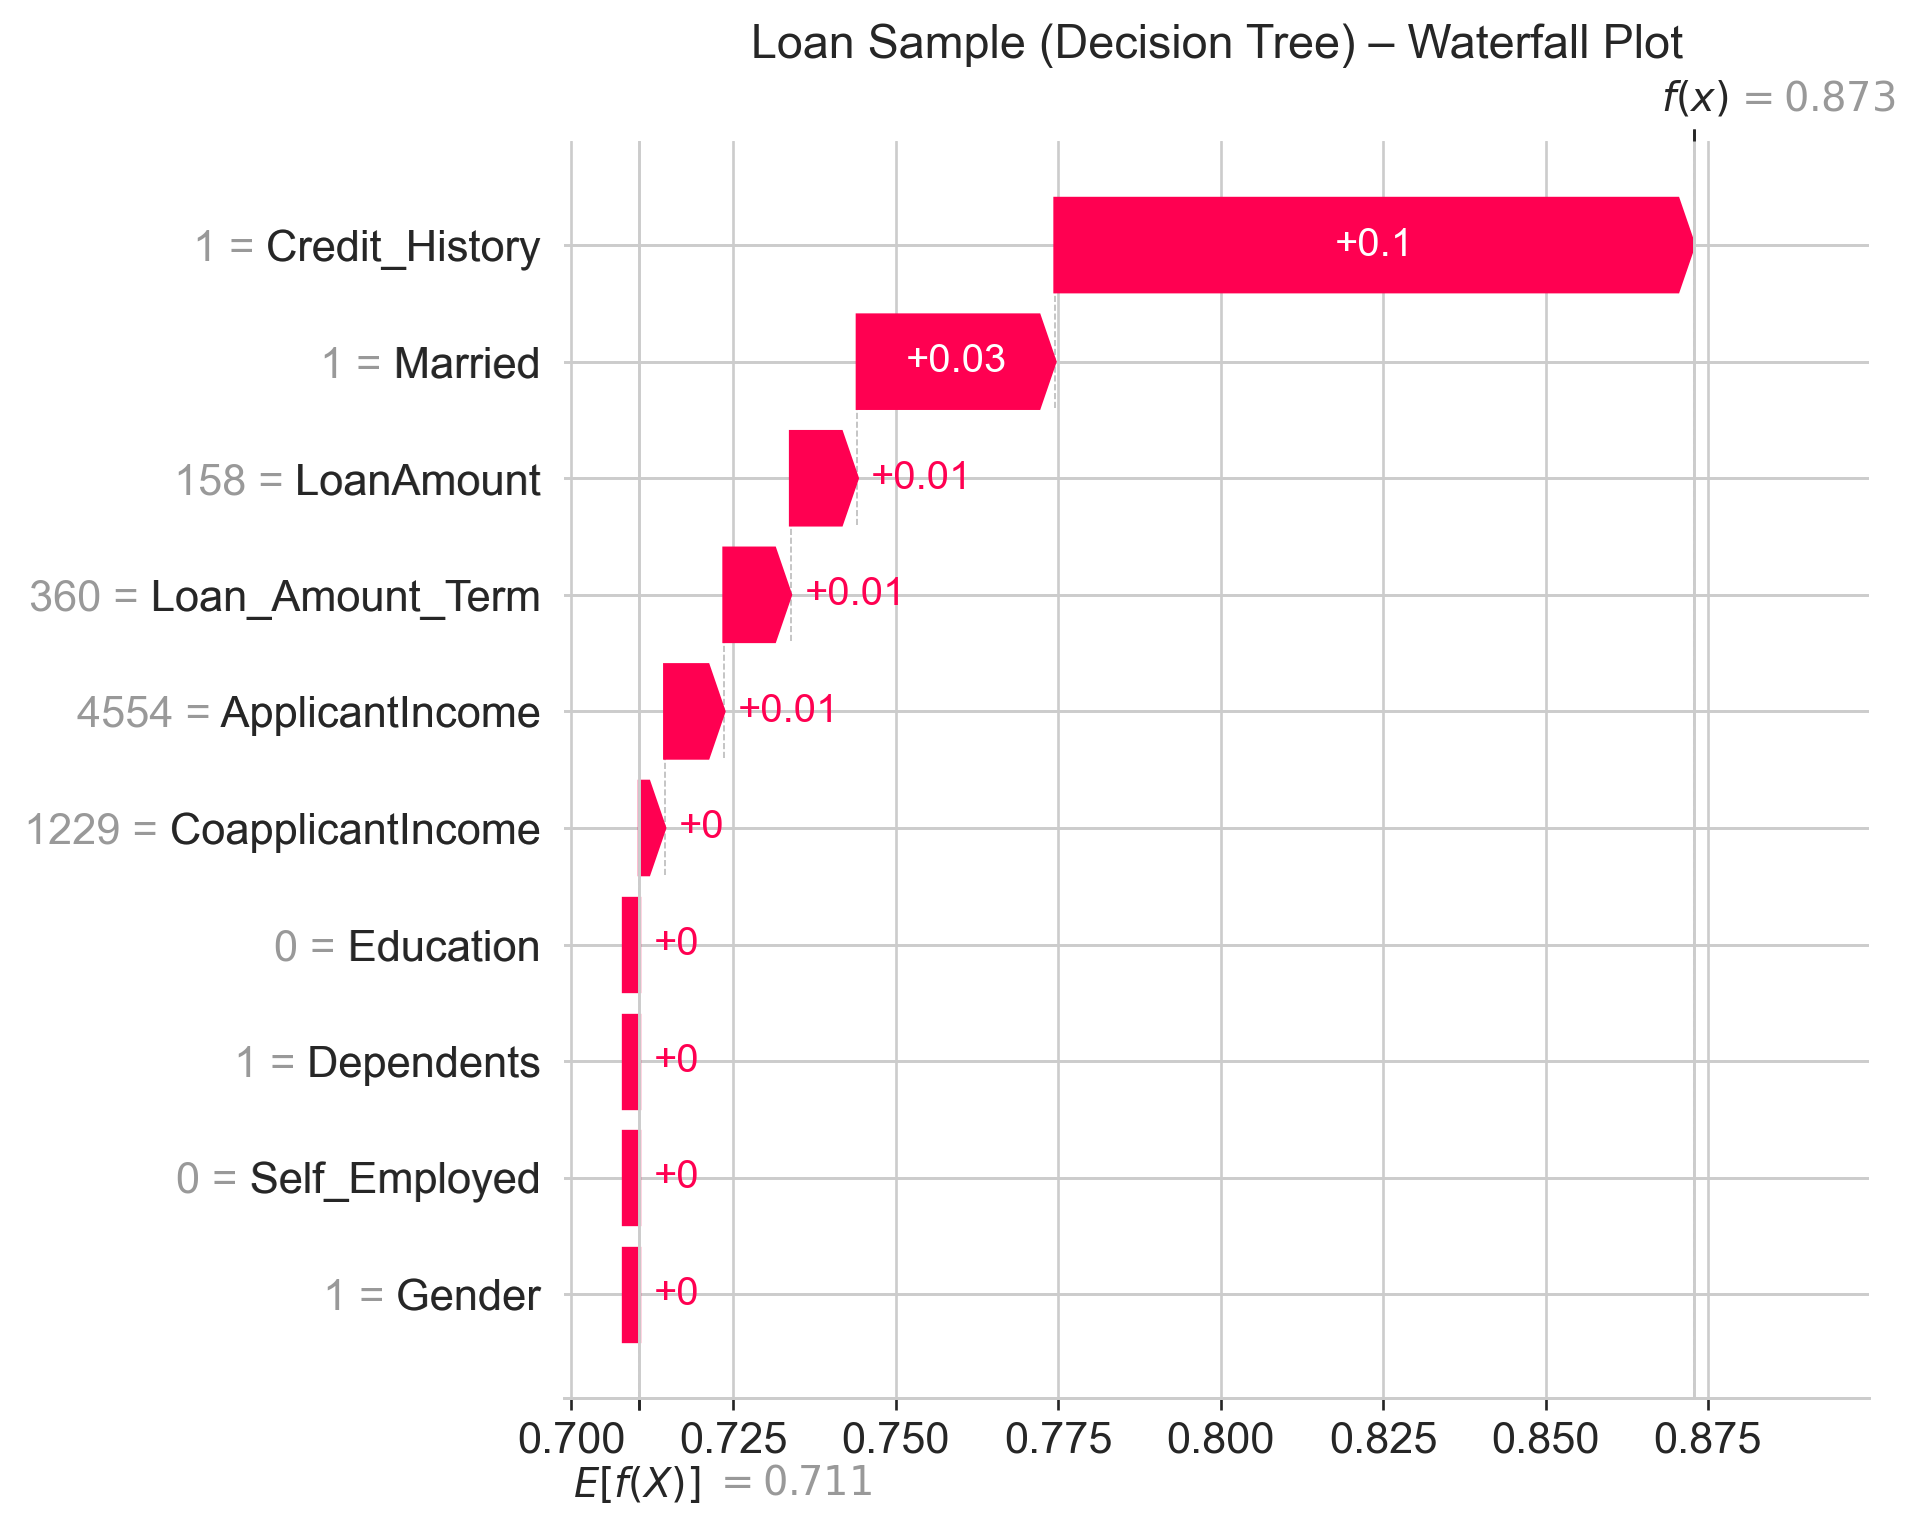

In [39]:
# %% Individual Prediction Explanation – Force & Waterfall Plots (Loan)
idx = 0

def explain_sample(explainer, shap_values, X_row, feature_names, title_prefix, save_prefix):
    """Generate force and waterfall plots for a single sample (binary classification)."""
    # ---- Extract SHAP values for this sample (positive class) ----
    # Get full SHAP array (3D or 2D)
    if hasattr(shap_values, 'values'):
        arr = shap_values.values
    else:
        arr = shap_values
    # Select positive class (index 1)
    if len(arr.shape) == 3:
        arr = arr[:, :, 1]
    else:
        arr = arr  # already 2D
    # Get 1D array for this sample
    sv = arr[idx]  # shape (n_features,)
    
    # Base value (positive class)
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)):
        base_val = base_val[1]
    
    # ---- Force Plot (static) ----
    shap.initjs()
    force_plot = shap.force_plot(
        base_val,
        sv,
        X_row,
        feature_names=feature_names,
        matplotlib=True,
        show=False
    )
    plt.title(f'{title_prefix} – Force Plot')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_force.png', dpi=300)
    plt.show()
    
    # ---- Waterfall Plot ----
    # Create Explanation object for this sample
    exp = shap.Explanation(
        values=sv,
        base_values=base_val,
        data=X_row,
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f'{title_prefix} – Waterfall Plot')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_waterfall.png', dpi=300)
    plt.show()

# Logistic Regression
explain_sample(
    explainer_lr_loan,
    shap_values_lr_loan,
    X_test.iloc[idx],
    X.columns,
    'Loan Sample (Logistic Regression)',
    f'plots/loan_lr_sample_{idx}'
)

# Decision Tree
explain_sample(
    explainer_dt_loan,
    shap_values_dt_loan,
    X_test.iloc[idx],
    X.columns,
    'Loan Sample (Decision Tree)',
    f'plots/loan_dt_sample_{idx}'
)

## Summary and Next Steps

**Accomplished:**
- Introduced SHAP (SHapley Additive exPlanations) for model interpretability, explaining both global feature importance and local individual predictions.
- Applied SHAP to a **Logistic Regression** model on the Breast Cancer dataset, achieving **96% accuracy** and identifying key features like `worst radius`, `worst texture`, and `mean concave points`.
- Applied SHAP to a **Logistic Regression** and a **Decision Tree** on a Loan Approval dataset (mixed categorical/numerical features), achieving **78% accuracy** (Logistic Regression) and **74% accuracy** (Decision Tree).
- Used multiple SHAP visualisations:
  - **Summary plots** (beeswarm) to show global feature importance and direction of impact.
  - **Bar plots** to rank features by mean absolute SHAP value.
  - **Waterfall plots** to explain individual predictions.
  - **Force plots** to visualise SHAP values as forces pushing the prediction from the base value.
  - **Dependence plots** to explore feature interactions (e.g., Credit_History).
- Demonstrated that SHAP provides consistent explanations across different model types (linear and tree‑based).

**Key Results (Breast Cancer – Logistic Regression):**
| Metric | Value |
|--------|-------|
| Test Accuracy | **96%** |
| Top 5 Features | `worst radius`, `worst texture`, `mean concave points`, `worst perimeter`, `worst area` |
| SHAP Insights | Features with high values increase the probability of malignant prediction; negative contributions decrease it. |

**Key Results (Loan Approval – Logistic Regression):**
| Metric | Value |
|--------|-------|
| Test Accuracy | **78%** |
| Top Features | `Credit_History`, `ApplicantIncome`, `LoanAmount`, `CoapplicantIncome`, `Married` |
| SHAP Insights | `Credit_History` has the strongest positive impact: a good credit history significantly increases the likelihood of loan approval. `ApplicantIncome` and `LoanAmount` also contribute, with higher incomes and smaller loan amounts being favourable. |

**Key Results (Loan Approval – Decision Tree):**
| Metric | Value |
|--------|-------|
| Test Accuracy | **74%** |
| Top Features | `Credit_History`, `ApplicantIncome`, `LoanAmount`, `Married` |
| SHAP Insights | The decision tree and logistic regression agree on the most important features, but the tree captures threshold effects (e.g., `ApplicantIncome > 5000` has a distinct impact). |

**Key Insights:**
- **SHAP is model‑agnostic** – it works equally well for linear models (Logistic Regression) and non‑linear models (Decision Tree), making it a powerful tool for comparing explanations across model families.
- **Global vs Local Explanations** – summary plots provide a high‑level overview, while waterfall and force plots allow deep inspection of individual predictions. This combination is essential for building trust in high‑stakes applications (e.g., healthcare, finance).
- **Feature Importance** – the most important feature in both loan models is `Credit_History`, which dominates all other features. This suggests that loan approval decisions are heavily influenced by credit history, which is consistent with real‑world lending practices.
- **Dependence Plots** – revealed that `Credit_History` has a binary‑like effect: the SHAP value jumps significantly when `Credit_History = 1`, indicating that a good credit history is a strong positive signal.
- **Linear vs Non‑linear Models** – the logistic regression provides linear, additive explanations, while the decision tree captures interactions and thresholds. SHAP successfully highlights these differences.

**Suggested Next Steps:**
1. **Explainability Dashboard:** Build an interactive dashboard using `shap` and `streamlit` to allow users to explore model predictions and explanations dynamically.
2. **Comparison with LIME:** Compare SHAP with LIME on the same models to understand the trade‑offs between the two methods (e.g., computational cost, stability, consistency).
3. **Feature Interactions:** Use SHAP interaction values to explore feature interactions in more depth (e.g., how `Credit_History` interacts with `ApplicantIncome`).
4. **Model‑Specific Explainers:** Experiment with `shap.TreeExplainer` for tree‑based models and `shap.DeepExplainer` for neural networks.
5. **Real‑World Deployment:** Integrate SHAP explanations into a production system (e.g., via an API) to provide live, interpretable predictions for end‑users.
6. **Causal Inference:** Use SHAP values as a starting point for causal analysis (e.g., using SHAP to identify potential confounders or drivers of outcomes).
7. **Automated Reporting:** Generate automated SHAP reports for model monitoring and auditing.

**Final Reflection:**
This notebook provides a thorough introduction to SHAP, demonstrating its utility in explaining both linear and non‑linear models. The combination of global and local explanations makes it a valuable tool for model interpretability, especially in high‑stakes domains like healthcare and finance. The case studies highlight SHAP's practical application and its ability to build trust in machine learning models by revealing the reasoning behind predictions. As models become more complex and are deployed in critical applications, explainability is no longer optional – it is essential. SHAP provides a rigorous, mathematically sound foundation for achieving this.